L'EDA a trois objectifs :
1.	Comprendre le portefeuille d’entraînement et la cible.
2.	Étudier les relations entre variables disponibles à l’octroi et défaut.
3.	Diagnostiquer la dérive train–validation–test, sans utiliser le test pour choisir des variables ou des seuils.

# P2 — Credit Risk Scoring

## 02 — Analyse exploratoire des données

Ce notebook réalise l'analyse exploratoire des jeux de données préparés pour
la modélisation du risque de crédit.

Les données proviennent du notebook `01_data_preparation.ipynb`. Elles
contiennent uniquement des prêts de 36 mois intégralement matures, avec un
split strictement chronologique :

- train : 2007 à 2013 ;
- validation : 2014 ;
- test final : 2015.

L'EDA est conduite principalement sur le jeu d'entraînement. Les jeux de
validation et de test servent uniquement à diagnostiquer une éventuelle dérive
temporelle des variables, sans guider la sélection des variables ou des
transformations du modèle.


In [1]:
# ============================================================
# 1. IMPORTS ET CONFIGURATION
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Configuration générale
# ------------------------------------------------------------

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}"
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep",
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)


# ------------------------------------------------------------
# Chemins du projet
# ------------------------------------------------------------

def find_project_root(start_path: Path) -> Path:
    """Trouve la racine du projet via le fichier pyproject.toml."""
    current_path = start_path.resolve()

    for candidate_path in [current_path, *current_path.parents]:
        if (candidate_path / "pyproject.toml").exists():
            return candidate_path

    raise FileNotFoundError(
        "Racine du projet introuvable : pyproject.toml absent."
    )


PROJECT_DIR = find_project_root(Path.cwd())

DATA_PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
OUTPUT_TABLES_DIR = PROJECT_DIR / "outputs" / "tables"

TRAIN_FILE = DATA_PROCESSED_DIR / "train_v1.parquet"
VALIDATION_FILE = DATA_PROCESSED_DIR / "validation_v1.parquet"
TEST_FILE = DATA_PROCESSED_DIR / "test_v1.parquet"

for file_path in [
    TRAIN_FILE,
    VALIDATION_FILE,
    TEST_FILE,
]:
    assert file_path.exists(), (
        f"Fichier introuvable : {file_path}"
    )

print(f"Racine projet : {PROJECT_DIR}")
print(f"Train         : {TRAIN_FILE.name}")
print(f"Validation    : {VALIDATION_FILE.name}")
print(f"Test          : {TEST_FILE.name}")


Racine projet : /Users/kwamekristianlaban/Documents/Projet_perso/P2
Train         : train_v1.parquet
Validation    : validation_v1.parquet
Test          : test_v1.parquet


## Chargement des données

Les trois jeux sont chargés directement depuis les fichiers Parquet générés
lors de la préparation des données.

Les variables utilisées pour l'EDA correspondent strictement à la V1 : elles
sont disponibles à l'octroi, stables entre les périodes et ne contiennent pas
d'information post-octroi.


In [2]:
# ============================================================
# 2. CHARGEMENT DES JEUX PRÉPARÉS
# ============================================================

train_df = pd.read_parquet(
    TRAIN_FILE,
    engine="pyarrow",
)

validation_df = pd.read_parquet(
    VALIDATION_FILE,
    engine="pyarrow",
)

test_df = pd.read_parquet(
    TEST_FILE,
    engine="pyarrow",
)

SPLIT_ORDER = ["train", "validation", "test"]

train_df["dataset_split"] = "train"
validation_df["dataset_split"] = "validation"
test_df["dataset_split"] = "test"

all_df = pd.concat(
    [
        train_df,
        validation_df,
        test_df,
    ],
    ignore_index=True,
)

print(f"Train      : {train_df.shape}")
print(f"Validation : {validation_df.shape}")
print(f"Test       : {test_df.shape}")
print(f"Total      : {all_df.shape}")


Train      : (172988, 25)
Validation : (162570, 25)
Test       : (283026, 25)
Total      : (618584, 25)


## Contrôles initiaux

Nous vérifions que les jeux chargés correspondent au split attendu, que la
cible est binaire et que les périodes ne se chevauchent pas.

Ces contrôles garantissent que les résultats de l'EDA reposent sur la même
base de données que les futurs modèles.


In [3]:
# ============================================================
# 3. CONTRÔLES INITIAUX
# ============================================================

TARGET = "default_flag"

EXPECTED_FEATURES = [
    "loan_amnt",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "acc_now_delinq",
    "chargeoff_within_12_mths",
    "collections_12_mths_ex_med",
    "pub_rec_bankruptcies",
    "tax_liens",
    "fico_score",
    "credit_history_months",
    "emp_length_years",
    "home_ownership",
    "purpose",
    "verification_status",
]

METADATA_COLUMNS = [
    "id",
    "issue_d",
    "dataset_split",
    TARGET,
]

assert set(EXPECTED_FEATURES).issubset(
    train_df.columns
), "Des variables attendues sont absentes du train."

assert train_df[TARGET].isin([0, 1]).all()
assert validation_df[TARGET].isin([0, 1]).all()
assert test_df[TARGET].isin([0, 1]).all()

assert train_df["issue_d"].max() < validation_df["issue_d"].min()
assert validation_df["issue_d"].max() < test_df["issue_d"].min()

initial_summary = (
    all_df
    .groupby("dataset_split", observed=True)
    .agg(
        start_date=("issue_d", "min"),
        end_date=("issue_d", "max"),
        n_loans=("id", "size"),
        n_defaults=(TARGET, "sum"),
        default_rate=(TARGET, "mean"),
    )
    .reindex(SPLIT_ORDER)
    .reset_index()
)

initial_summary["start_date"] = (
    initial_summary["start_date"]
    .dt.strftime("%Y-%m")
)

initial_summary["end_date"] = (
    initial_summary["end_date"]
    .dt.strftime("%Y-%m")
)

display(initial_summary)

print("Contrôles de cohérence : OK")


,dataset_split,start_date,end_date,n_loans,n_defaults,default_rate
0,train,2007-06,2013-12,172988,21508,0.1243
1,validation,2014-01,2014-12,162570,22315,0.1373
2,test,2015-01,2015-12,283026,42132,0.1489


Contrôles de cohérence : OK


### Lecture initiale des jeux

Les trois jeux chargés respectent le découpage temporel défini lors de la
préparation : le train couvre juin 2007 à décembre 2013, la validation couvre
2014 et le test final couvre 2015.

Le taux de défaut progresse de 12,4 % dans le train à 13,7 % en validation,
puis 14,9 % dans le test. Cette évolution confirme une dérive temporelle du
portefeuille et rend l'évaluation hors échantillon plus exigeante.

Les trois périodes comportent un volume substantiel de défauts. Elles sont
donc adaptées à l'analyse exploratoire, à la sélection sur validation et à
l'évaluation finale sur test.


## Analyse de la cible dans le train

La cible `default_flag` vaut 1 lorsqu'un prêt est en défaut et 0 lorsqu'il a
été entièrement remboursé.

Cette section décrit le niveau de risque de référence dans le jeu
d'entraînement. L'analyse est volontairement limitée au train : la validation
et le test resteront réservés au diagnostic de dérive et à l'évaluation des
futurs modèles.


In [4]:
# ============================================================
# 4. DISTRIBUTION DE LA CIBLE DANS LE TRAIN
# ============================================================

target_summary_train = (
    train_df[TARGET]
    .value_counts()
    .rename_axis("default_flag")
    .reset_index(name="n_loans")
    .sort_values("default_flag")
    .reset_index(drop=True)
)

target_summary_train["target_label"] = (
    target_summary_train["default_flag"]
    .map(
        {
            0: "Non-défaut",
            1: "Défaut",
        }
    )
)

target_summary_train["share"] = (
    target_summary_train["n_loans"]
    / target_summary_train["n_loans"].sum()
)

target_summary_train = target_summary_train[
    [
        "default_flag",
        "target_label",
        "n_loans",
        "share",
    ]
]

display(target_summary_train)

train_default_rate = train_df[TARGET].mean()

print(f"Taux de défaut du train : {train_default_rate:.2%}")
print(
    "Rapport non-défauts / défauts : "
    f"{(1 - train_default_rate) / train_default_rate:.2f}"
)


,default_flag,target_label,n_loans,share
0,0,Non-défaut,151480,0.8757
1,1,Défaut,21508,0.1243


Taux de défaut du train : 12.43%
Rapport non-défauts / défauts : 7.04


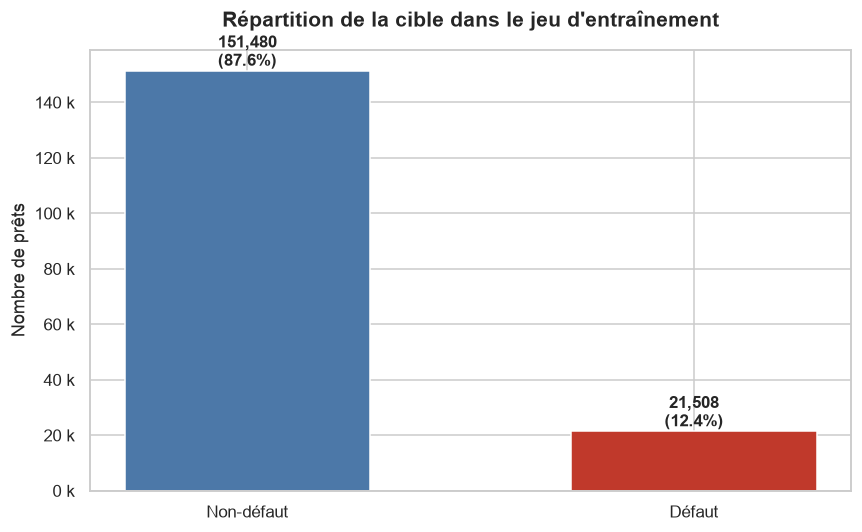

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/eda_train_target_distribution.png


In [5]:
#Gaphique - repartition de la cible
target_colors = {
    "Non-défaut": "#4C78A8",
    "Défaut": "#C0392B",
}

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    target_summary_train["target_label"],
    target_summary_train["n_loans"],
    color=[
        target_colors[label]
        for label in target_summary_train["target_label"]
    ],
    width=0.55,
)

for bar, (_, row) in zip(bars, target_summary_train.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{row['n_loans']:,}\n({row['share']:.1%})",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_title(
    "Répartition de la cible dans le jeu d'entraînement",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("")
ax.set_ylabel("Nombre de prêts")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value / 1_000:.0f} k")
)

plt.tight_layout()

figure_path = (
    OUTPUT_FIGURES_DIR
    / "eda_train_target_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(f"Figure exportée : {figure_path}")


### Évolution annuelle du risque dans le train

Le jeu d'entraînement couvre plusieurs millésimes, de 2007 à 2013. Nous
observons son évolution interne pour distinguer les changements de risque
historiques de la dérive plus récente déjà observée entre train, validation et
test.


In [6]:
#tableau annuel
train_df["issue_year"] = train_df["issue_d"].dt.year

train_yearly_target_summary = (
    train_df
    .groupby("issue_year", observed=True)
    .agg(
        n_loans=("id", "size"),
        n_defaults=(TARGET, "sum"),
        default_rate=(TARGET, "mean"),
    )
    .reset_index()
)

train_yearly_target_summary["share_loans"] = (
    train_yearly_target_summary["n_loans"]
    / train_yearly_target_summary["n_loans"].sum()
)

display(train_yearly_target_summary)


,issue_year,n_loans,n_defaults,default_rate,share_loans
0,2007,251,45,0.1793,0.0015
1,2008,1562,247,0.1581,0.0090
2,2009,4716,594,0.1260,0.0273
3,2010,8466,842,0.0995,0.0489
4,2011,14101,1499,0.1063,0.0815
5,2012,43470,5903,0.1358,0.2513
6,2013,100422,12378,0.1233,0.5805


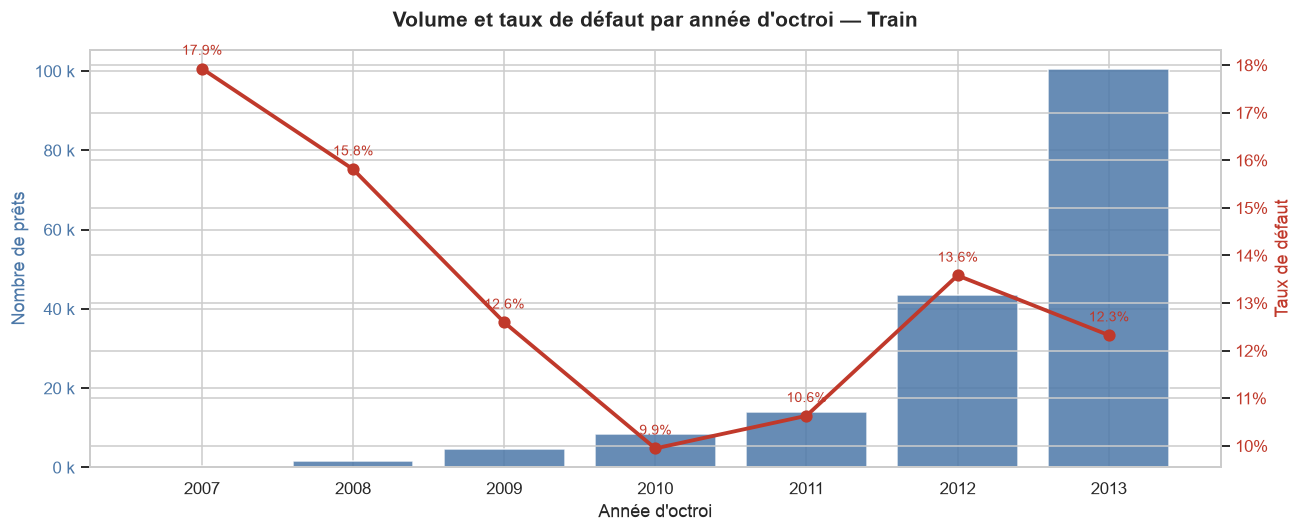

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/eda_train_default_rate_by_year.png


In [7]:
fig, ax1 = plt.subplots(figsize=(12, 5))

bar_color = "#4C78A8"
line_color = "#C0392B"

bars = ax1.bar(
    train_yearly_target_summary["issue_year"].astype(str),
    train_yearly_target_summary["n_loans"],
    color=bar_color,
    alpha=0.85,
    label="Volume de prêts",
)

ax1.set_xlabel("Année d'octroi")
ax1.set_ylabel("Nombre de prêts", color=bar_color)
ax1.tick_params(axis="y", labelcolor=bar_color)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value / 1_000:.0f} k")
)

ax2 = ax1.twinx()

ax2.plot(
    train_yearly_target_summary["issue_year"].astype(str),
    train_yearly_target_summary["default_rate"],
    color=line_color,
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Taux de défaut",
)

for _, row in train_yearly_target_summary.iterrows():
    ax2.annotate(
        f"{row['default_rate']:.1%}",
        (str(row["issue_year"]), row["default_rate"]),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=line_color,
    )

ax2.set_ylabel("Taux de défaut", color=line_color)
ax2.tick_params(axis="y", labelcolor=line_color)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax1.set_title(
    "Volume et taux de défaut par année d'octroi — Train",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

plt.tight_layout()

figure_path = (
    OUTPUT_FIGURES_DIR
    / "eda_train_default_rate_by_year.png"
)

plt.savefig(
    figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(f"Figure exportée : {figure_path}")


### Interprétation

Le taux de défaut global du train constitue le niveau de risque de référence
que les futurs modèles devront estimer au niveau individuel.

La classe défaut est minoritaire, mais elle reste suffisamment représentée
pour analyser les déterminants du risque et entraîner des modèles supervisés.
L'accuracy ne sera donc pas utilisée comme métrique principale : les modèles
seront évalués avec des mesures de discrimination et de calibration.

L'évolution annuelle du taux de défaut au sein du train confirme que le risque
n'est pas parfaitement constant dans le temps. Cette variation historique
justifie l'utilisation d'une validation et d'un test strictement postérieurs à
la période d'entraînement.


### Interprétation

Le jeu d'entraînement contient 172 988 prêts, dont 21 508 défauts, soit un
taux de défaut global de 12,4 %. La classe défaut est minoritaire, mais reste
suffisamment représentée pour entraîner et évaluer des modèles supervisés.

Un modèle prédisant systématiquement le non-défaut atteindrait une accuracy
de 87,6 %, sans identifier aucun défaut. Les futurs modèles seront donc
évalués avec des métriques adaptées au risque de crédit : ROC-AUC, Gini, KS,
AUC-PR, Brier score et courbes de calibration.

Le taux de défaut varie au sein du train, passant d'environ 10 % en 2010 à
plus de 13 % en 2012. Les cohortes anciennes sont de faible volume ; les
millésimes 2012 et 2013 concentrent l'essentiel des prêts et constituent la
part la plus représentative du jeu d'entraînement.


## Analyse exploratoire des variables numériques

Cette section décrit les variables numériques du jeu d'entraînement et leur
relation avec le défaut.

L'analyse repose sur trois niveaux :

- statistiques descriptives par classe de risque ;
- distributions comparées entre défaut et non-défaut ;
- taux de défaut par décile calculé exclusivement sur le train.

Les déciles ne constituent pas encore une transformation de modèle. Ils servent
à détecter les variables discriminantes, les relations non linéaires et les
valeurs extrêmes qui devront être traitées dans les pipelines de modélisation.


In [8]:
# ============================================================
# 5. ANALYSE DES VARIABLES NUMÉRIQUES
# ============================================================

NUMERICAL_FEATURES = [
    "loan_amnt",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "acc_now_delinq",
    "chargeoff_within_12_mths",
    "collections_12_mths_ex_med",
    "pub_rec_bankruptcies",
    "tax_liens",
    "fico_score",
    "credit_history_months",
    "emp_length_years",
]

assert all(
    feature in train_df.columns
    for feature in NUMERICAL_FEATURES
), "Une variable numérique attendue est absente du train."

print(f"Nombre de variables numériques : {len(NUMERICAL_FEATURES)}")


Nombre de variables numériques : 18


In [9]:
# Statistiques descriptives globales et par classe de la cible
numeric_summary_records = []

for feature in NUMERICAL_FEATURES:
    for target_value, target_label in [
        (0, "Non-défaut"),
        (1, "Défaut"),
    ]:
        values = train_df.loc[
            train_df[TARGET] == target_value,
            feature,
        ]

        numeric_summary_records.append(
            {
                "variable": feature,
                "target_group": target_label,
                "n_observations": values.notna().sum(),
                "missing_rate": values.isna().mean(),
                "mean": values.mean(),
                "median": values.median(),
                "p05": values.quantile(0.05),
                "p25": values.quantile(0.25),
                "p75": values.quantile(0.75),
                "p95": values.quantile(0.95),
            }
        )

numeric_summary_by_target = pd.DataFrame(
    numeric_summary_records
)

display(numeric_summary_by_target)


,variable,target_group,n_observations,missing_rate,mean,median,p05,p25,p75,p95
0,loan_amnt,Non-défaut,151480,0.0000,"11,949.8893","10,000.0000","3,000.0000","6,500.0000","15,281.2500","25,600.0000"
1,loan_amnt,Défaut,21508,0.0000,"11,569.5299","10,000.0000","3,000.0000","6,350.0000","15,000.0000","25,450.0000"
2,annual_inc,Non-défaut,151480,0.0000,"70,666.0046","60,000.0000","26,000.0000","43,000.0000","85,000.0000","145,000.0000"
3,annual_inc,Défaut,21508,0.0000,"60,501.9942","51,000.0000","24,000.0000","37,000.0000","72,000.0000","125,000.0000"
4,dti,Non-défaut,151480,0.0000,15.8968,15.5200,4.0000,10.1800,21.3000,29.0900
5,dti,Défaut,21508,0.0000,17.3834,17.3000,4.7400,11.6800,23.0000,30.2100
6,delinq_2yrs,Non-défaut,151480,0.0000,0.2189,0.0000,0.0000,0.0000,0.0000,1.0000
7,delinq_2yrs,Défaut,21508,0.0000,0.2317,0.0000,0.0000,0.0000,0.0000,1.0000
8,inq_last_6mths,Non-défaut,151480,0.0000,0.7684,0.0000,0.0000,0.0000,1.0000,3.0000
9,inq_last_6mths,Défaut,21508,0.0000,0.9482,1.0000,0.0000,0.0000,2.0000,3.0000


Variables prioritaires
Les distributions de certaines variables sont particulièrement importantes en crédit : le score FICO, le ratio d’endettement, le revenu, l’utilisation du crédit, le montant demandé, les demandes récentes de crédit et l’ancienneté de crédit.

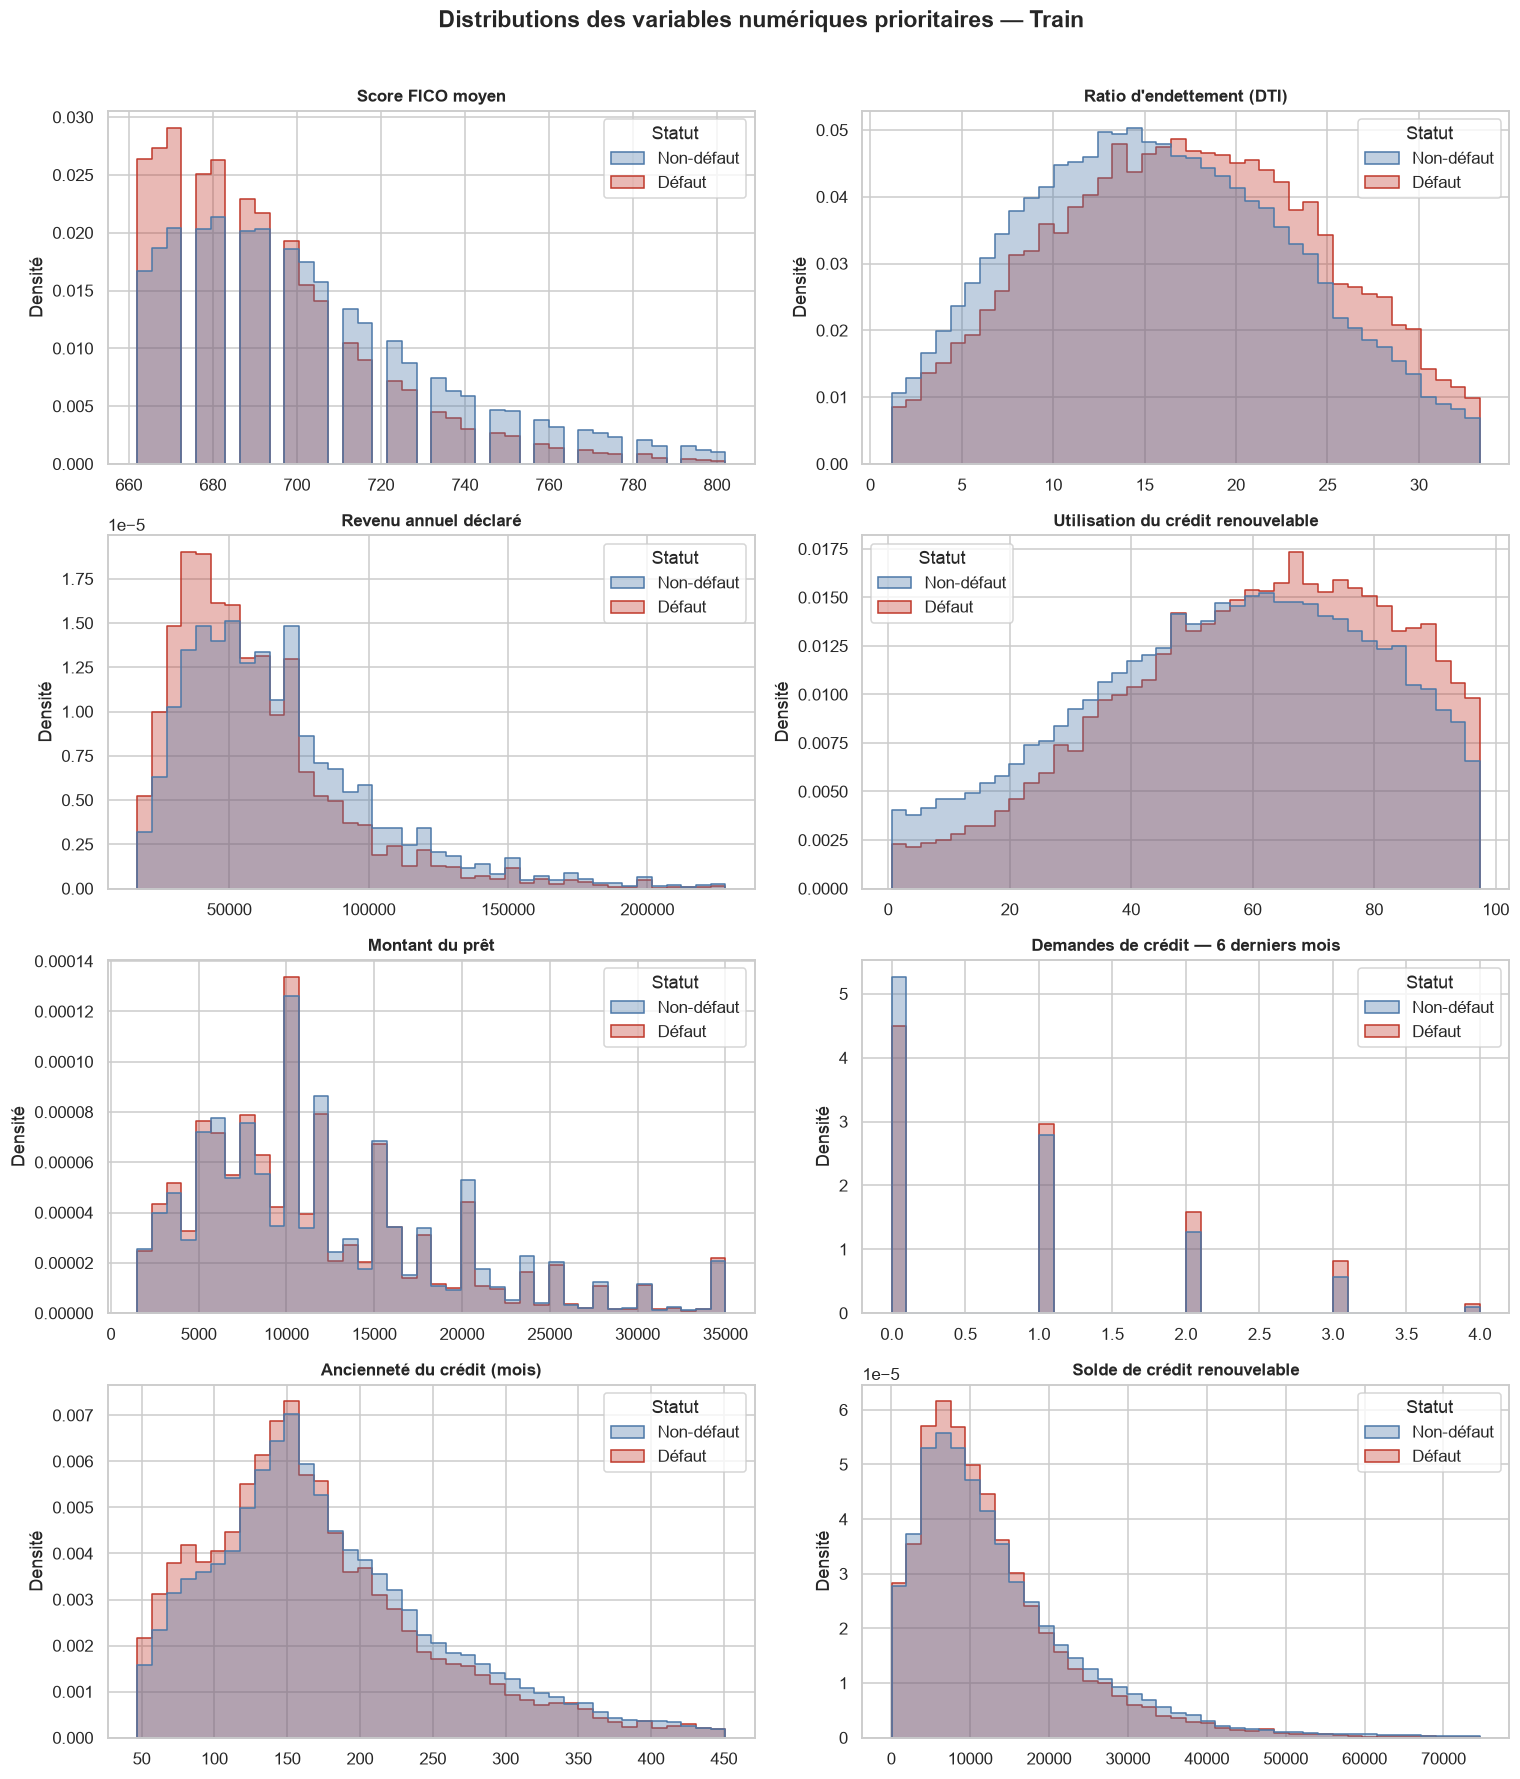

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/eda_priority_numerical_distributions.png


In [10]:
#Distribution comparée
PRIORITY_NUMERICAL_FEATURES = [
    "fico_score",
    "dti",
    "annual_inc",
    "revol_util",
    "loan_amnt",
    "inq_last_6mths",
    "credit_history_months",
    "revol_bal",
]

FEATURE_LABELS = {
    "fico_score": "Score FICO moyen",
    "dti": "Ratio d'endettement (DTI)",
    "annual_inc": "Revenu annuel déclaré",
    "revol_util": "Utilisation du crédit renouvelable",
    "loan_amnt": "Montant du prêt",
    "inq_last_6mths": "Demandes de crédit — 6 derniers mois",
    "credit_history_months": "Ancienneté du crédit (mois)",
    "revol_bal": "Solde de crédit renouvelable",
}

# Limites graphiques robustes : les queues extrêmes sont coupées
# uniquement pour améliorer la lisibilité des graphiques.
PLOT_LOWER_QUANTILE = 0.01
PLOT_UPPER_QUANTILE = 0.99

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 16),
)

axes = axes.flatten()

for ax, feature in zip(axes, PRIORITY_NUMERICAL_FEATURES):
    lower_bound = train_df[feature].quantile(PLOT_LOWER_QUANTILE)
    upper_bound = train_df[feature].quantile(PLOT_UPPER_QUANTILE)

    plot_df = train_df.loc[
        train_df[feature].between(
            lower_bound,
            upper_bound,
            inclusive="both",
        ),
        [feature, TARGET],
    ].copy()

    sns.histplot(
        data=plot_df,
        x=feature,
        hue=TARGET,
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        fill=True,
        alpha=0.35,
        palette={
            0: "#4C78A8",
            1: "#C0392B",
        },
        ax=ax,
    )

    ax.set_title(
        FEATURE_LABELS[feature],
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel("")
    ax.set_ylabel("Densité")

    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("Statut")
        for text, label in zip(
            legend.texts,
            ["Non-défaut", "Défaut"],
        ):
            text.set_text(label)

for ax in axes[len(PRIORITY_NUMERICAL_FEATURES):]:
    ax.remove()

fig.suptitle(
    "Distributions des variables numériques prioritaires — Train",
    fontsize=15,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()

figure_path = (
    OUTPUT_FIGURES_DIR
    / "eda_priority_numerical_distributions.png"
)

plt.savefig(
    figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(f"Figure exportée : {figure_path}")


### Taux de défaut par décile

Chaque variable est découpée en dix groupes de taille comparable à partir de
sa distribution dans le train. Le taux de défaut est ensuite calculé dans
chaque groupe.

Une relation monotone est particulièrement utile pour une scorecard
interprétable. Une relation non monotone peut néanmoins être informative,
notamment pour XGBoost, ou nécessiter un regroupement métier lors du binning.


In [11]:
def compute_default_rate_by_quantile(
    dataframe: pd.DataFrame,
    feature: str,
    target: str,
    n_quantiles: int = 10,
) -> pd.DataFrame:
    """
    Calcule le taux de défaut par quantile d'une variable numérique.

    Les bornes sont dérivées uniquement du dataframe passé en entrée.
    Les valeurs manquantes sont isolées dans une ligne distincte.
    """
    working_df = dataframe[[feature, target]].copy()

    non_missing_mask = working_df[feature].notna()

    non_missing_df = working_df.loc[
        non_missing_mask
    ].copy()

    try:
        non_missing_df["bin"] = pd.qcut(
            non_missing_df[feature],
            q=n_quantiles,
            duplicates="drop",
        )
    except ValueError:
        return pd.DataFrame(
            {
                "variable": [feature],
                "bin": ["Non exploitable : valeurs insuffisamment variées"],
                "n_loans": [len(non_missing_df)],
                "n_defaults": [non_missing_df[target].sum()],
                "default_rate": [non_missing_df[target].mean()],
                "mean_feature_value": [non_missing_df[feature].mean()],
            }
        )

    summary = (
        non_missing_df
        .groupby("bin", observed=True)
        .agg(
            n_loans=(target, "size"),
            n_defaults=(target, "sum"),
            default_rate=(target, "mean"),
            mean_feature_value=(feature, "mean"),
        )
        .reset_index()
    )

    summary["variable"] = feature
    summary["bin"] = summary["bin"].astype(str)

    missing_df = working_df.loc[
        ~non_missing_mask
    ]

    if not missing_df.empty:
        missing_summary = pd.DataFrame(
            {
                "variable": [feature],
                "bin": ["Missing"],
                "n_loans": [len(missing_df)],
                "n_defaults": [missing_df[target].sum()],
                "default_rate": [missing_df[target].mean()],
                "mean_feature_value": [np.nan],
            }
        )

        summary = pd.concat(
            [summary, missing_summary],
            ignore_index=True,
        )

    return summary[
        [
            "variable",
            "bin",
            "n_loans",
            "n_defaults",
            "default_rate",
            "mean_feature_value",
        ]
    ]


In [12]:
#Tableau
quantile_default_rate_summary = pd.concat(
    [
        compute_default_rate_by_quantile(
            dataframe=train_df,
            feature=feature,
            target=TARGET,
        )
        for feature in NUMERICAL_FEATURES
    ],
    ignore_index=True,
)

display(quantile_default_rate_summary)


,variable,bin,n_loans,n_defaults,default_rate,mean_feature_value
0,loan_amnt,"(499.999, 4000.0]",18017,2349,0.1304,"2,820.3738"
1,loan_amnt,"(4000.0, 6000.0]",22288,2779,0.1247,"5,319.4264"
2,loan_amnt,"(6000.0, 7500.0]",12843,1641,0.1278,"6,898.4933"
3,loan_amnt,"(7500.0, 9000.0]",17246,2313,0.1341,"8,323.0416"
4,loan_amnt,"(9000.0, 10000.0]",20599,2704,0.1313,"9,880.4687"
...,...,...,...,...,...,...
110,emp_length_years,"(4.0, 6.0]",24248,3041,0.1254,5.4453
111,emp_length_years,"(6.0, 7.0]",9702,1248,0.1286,7.0000
112,emp_length_years,"(7.0, 9.0]",14014,1720,0.1227,8.4415
113,emp_length_years,"(9.0, 10.0]",49550,5703,0.1151,10.0000


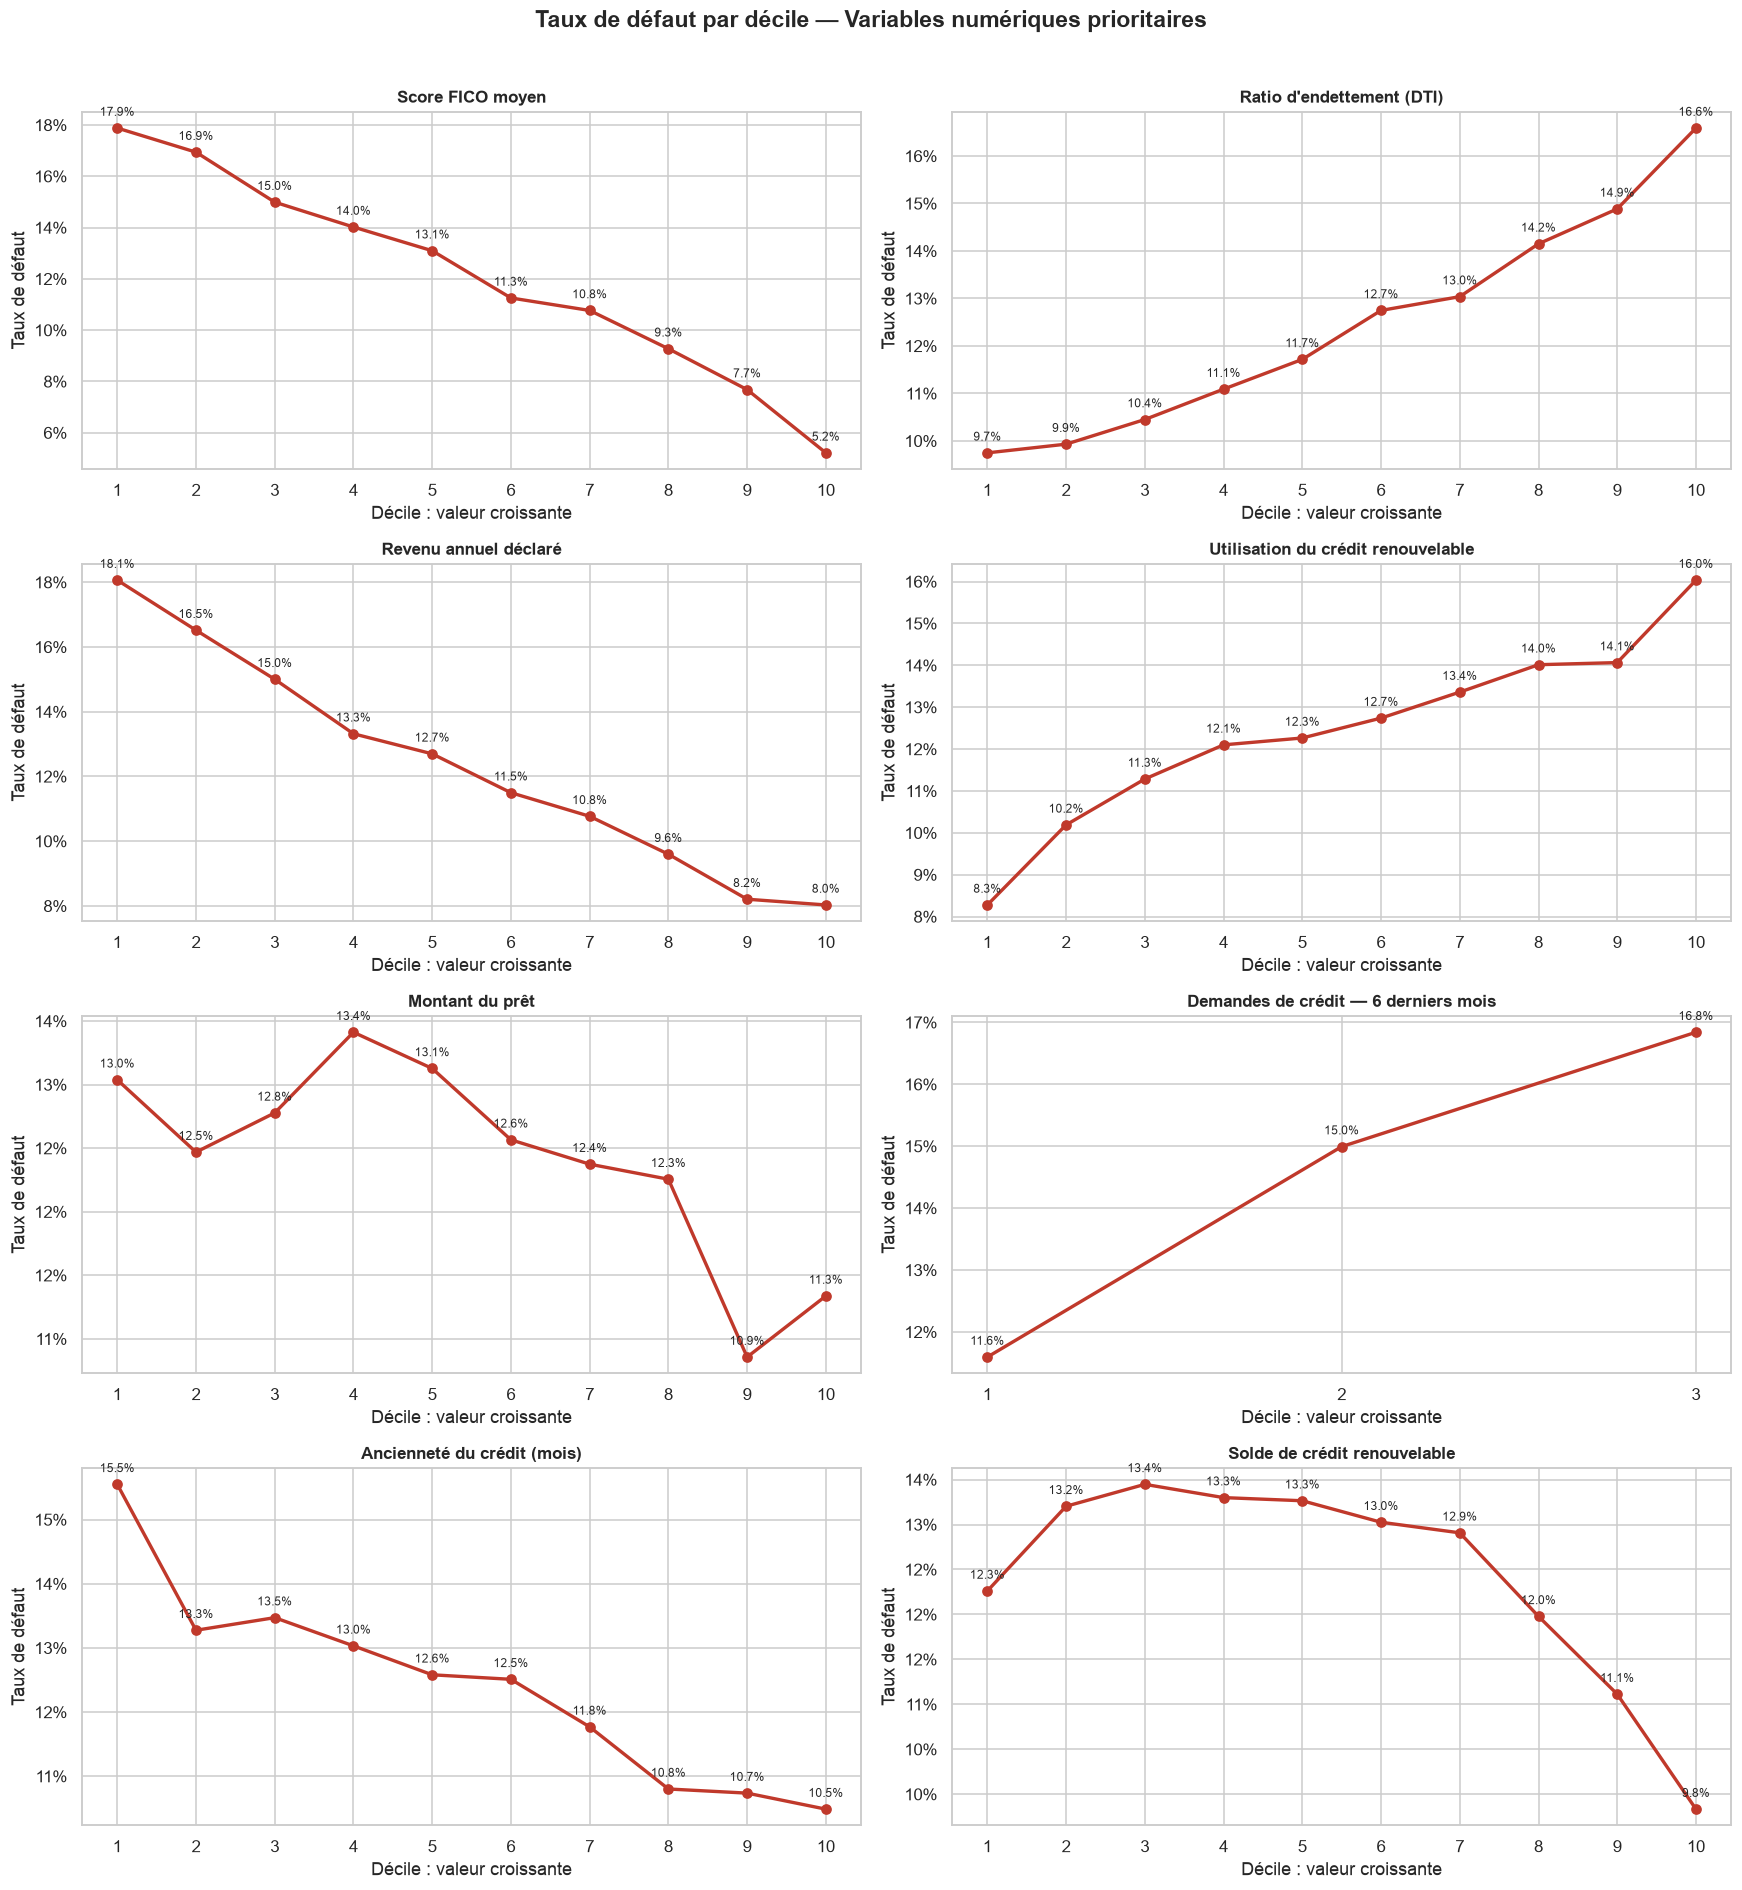

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/eda_default_rate_by_numerical_decile.png


In [13]:
#Graphique
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 17),
)

axes = axes.flatten()

for ax, feature in zip(axes, PRIORITY_NUMERICAL_FEATURES):
    feature_df = quantile_default_rate_summary.loc[
        (
            quantile_default_rate_summary["variable"] == feature
        )
        & (
            quantile_default_rate_summary["bin"] != "Missing"
        )
    ].copy()

    ax.plot(
        range(1, len(feature_df) + 1),
        feature_df["default_rate"],
        marker="o",
        linewidth=2.2,
        color="#C0392B",
    )

    for position, (_, row) in enumerate(
        feature_df.iterrows(),
        start=1,
    ):
        ax.annotate(
            f"{row['default_rate']:.1%}",
            (position, row["default_rate"]),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )

    ax.set_title(
        FEATURE_LABELS[feature],
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel("Décile : valeur croissante")
    ax.set_ylabel("Taux de défaut")
    ax.set_xticks(range(1, len(feature_df) + 1))
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda value, _: f"{value:.0%}"
        )
    )

for ax in axes[len(PRIORITY_NUMERICAL_FEATURES):]:
    ax.remove()

fig.suptitle(
    "Taux de défaut par décile — Variables numériques prioritaires",
    fontsize=15,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()

figure_path = (
    OUTPUT_FIGURES_DIR
    / "eda_default_rate_by_numerical_decile.png"
)

plt.savefig(
    figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(f"Figure exportée : {figure_path}")


In [14]:
#Export
numeric_summary_by_target.to_csv(
    OUTPUT_TABLES_DIR / "eda_numerical_summary_by_target.csv",
    index=False,
)

quantile_default_rate_summary.to_csv(
    OUTPUT_TABLES_DIR / "eda_default_rate_by_numerical_decile.csv",
    index=False,
)

print("Tables exportées :")
print(
    "-",
    OUTPUT_TABLES_DIR / "eda_numerical_summary_by_target.csv",
)
print(
    "-",
    OUTPUT_TABLES_DIR / "eda_default_rate_by_numerical_decile.csv",
)


Tables exportées :
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/eda_numerical_summary_by_target.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/eda_default_rate_by_numerical_decile.csv


### Interprétation

Les distributions comparées permettent d'identifier les variables dont les
profils diffèrent entre défaut et non-défaut. Les relations observées ne
constituent pas encore une preuve de causalité, mais elles orientent le choix
des transformations et du binning pour les futurs modèles.

Les taux de défaut par décile permettent de vérifier la direction et la forme
de la relation avec le risque. Une relation régulière et monotone facilitera
la construction d'une scorecard. Les relations plus complexes seront
particulièrement adaptées à l'approche non linéaire de XGBoost.

Les bornes utilisées dans cette analyse proviennent uniquement du train ; elles
ne doivent pas être ajustées à partir de la validation ou du test.


Les résultats sont très cohérents avec le risque de crédit : FICO, revenu, DTI, utilisation du crédit et demandes récentes montrent des relations nettes avec le défaut. Ces variables devront être prioritaires dans la scorecard et XGBoost.[Pièce jointe +1]
Signaux les plus forts
•	Score FICO : relation fortement monotone décroissante. Le taux de défaut passe de 17,9% dans le décile de FICO le plus bas à 5,2% dans le plus élevé ; c’est le signal individuel le plus clair de l’EDA.[Pièce jointe]
•	DTI : relation monotone croissante. Le défaut progresse de 9,7% pour les emprunteurs les moins endettés à 16,6% pour le décile le plus endetté.[Pièce jointe]
•	Revenu annuel : relation inverse régulière. Le défaut baisse de 18,1% dans le décile de revenu le plus faible à 8,0% dans le plus élevé.[Pièce jointe +1]
•	Utilisation du crédit renouvelable ( revol_util ) : relation croissante presque monotone, de 8,3% à 16,0% entre les déciles extrêmes.[Pièce jointe]
•	Demandes de crédit récentes ( inq_last_6mths ) : seules trois classes effectives apparaissent dans le découpage, mais le signal est net : environ 11,6%, 15,0%, puis 16,8% de défaut lorsque le nombre de demandes augmente.[Pièce jointe]
Variables complémentaires
L’ancienneté de crédit est protectrice : le défaut diminue d’environ 15,5% dans le décile le plus récent à 10,5% dans le plus ancien. La relation est globalement décroissante malgré une légère irrégularité dans les premiers déciles.[Pièce jointe]
Le solde de crédit renouvelable présente une relation moins directe : le taux de défaut augmente légèrement jusqu’aux déciles intermédiaires, puis baisse fortement aux niveaux les plus élevés. Cela suggère que le montant absolu du solde, seul, est moins informatif que son ratio d’utilisation ( revol_util ) ; il peut néanmoins apporter une information complémentaire à XGBoost.[Pièce jointe +1]
Le montant du prêt n’est pas monotone : le risque culmine autour des déciles intermédiaires, puis diminue pour les montants élevés, avant un léger rebond dans le dernier décile. Cette variable est à conserver, mais une scorecard devra employer un binning supervisé plutôt qu’imposer une relation linéaire.[Pièce jointe]
Implications modèles
•	Scorecard : binning monotone recommandé pour  fico_score ,  dti ,  annual_inc ,  revol_util ,  inq_last_6mths  et probablement  credit_history_months .
•	XGBoost : peut exploiter directement les formes non monotones de  loan_amnt  et  revol_bal , ainsi que les interactions entre revenu, endettement et utilisation du crédit.
•	Valeurs extrêmes :  annual_inc  et  revol_bal  sont très asymétriques à droite ; les graphiques ont déjà masqué les 1% extrêmes pour la lisibilité. Les pipelines devront appliquer des plafonds déterminés sur le train, et éventuellement une transformation logarithmique pour les modèles linéaires.[Pièce jointe]
Point à corriger
Le graphique par « décile » de  inq_last_6mths  ne présente que trois groupes, car c’est une variable discrète avec beaucoup de zéros. Ce n’est pas un défaut : il faudra traiter cette variable comme un compteur avec des groupes métier, par exemple  0 ,  1 ,  2 , puis  3+ , plutôt que chercher dix déciles artificiels.[Pièce jointe]

### Interprétation

Le score FICO, le ratio d'endettement, le revenu annuel et l'utilisation du
crédit renouvelable présentent des relations fortes et cohérentes avec le
défaut.

Le risque diminue nettement lorsque le score FICO, le revenu ou l'ancienneté
de crédit augmentent. À l'inverse, il progresse lorsque le ratio d'endettement,
l'utilisation du crédit renouvelable ou le nombre de demandes récentes de
crédit augmentent.

Ces relations sont particulièrement favorables à la construction d'une
scorecard interprétable : elles pourront être regroupées dans des intervalles
de risque monotones. Les variables dont la relation est moins régulière,
comme le montant du prêt ou le solde renouvelable, seront conservées pour être
évaluées dans les deux approches de modélisation.

Les variables très asymétriques, notamment le revenu annuel et le solde de
crédit renouvelable, nécessiteront un traitement des valeurs extrêmes calculé
uniquement sur le jeu d'entraînement.


### Comparaison des distributions par statut

Les boxplots complètent les histogrammes en comparant la médiane, les quartiles
et la dispersion des variables entre prêts en défaut et non-défaut.

Les valeurs extrêmes sont masquées pour améliorer la lecture. Elles ne sont pas
supprimées des données et seront traitées ultérieurement dans les pipelines de
modélisation à partir des seules données train.


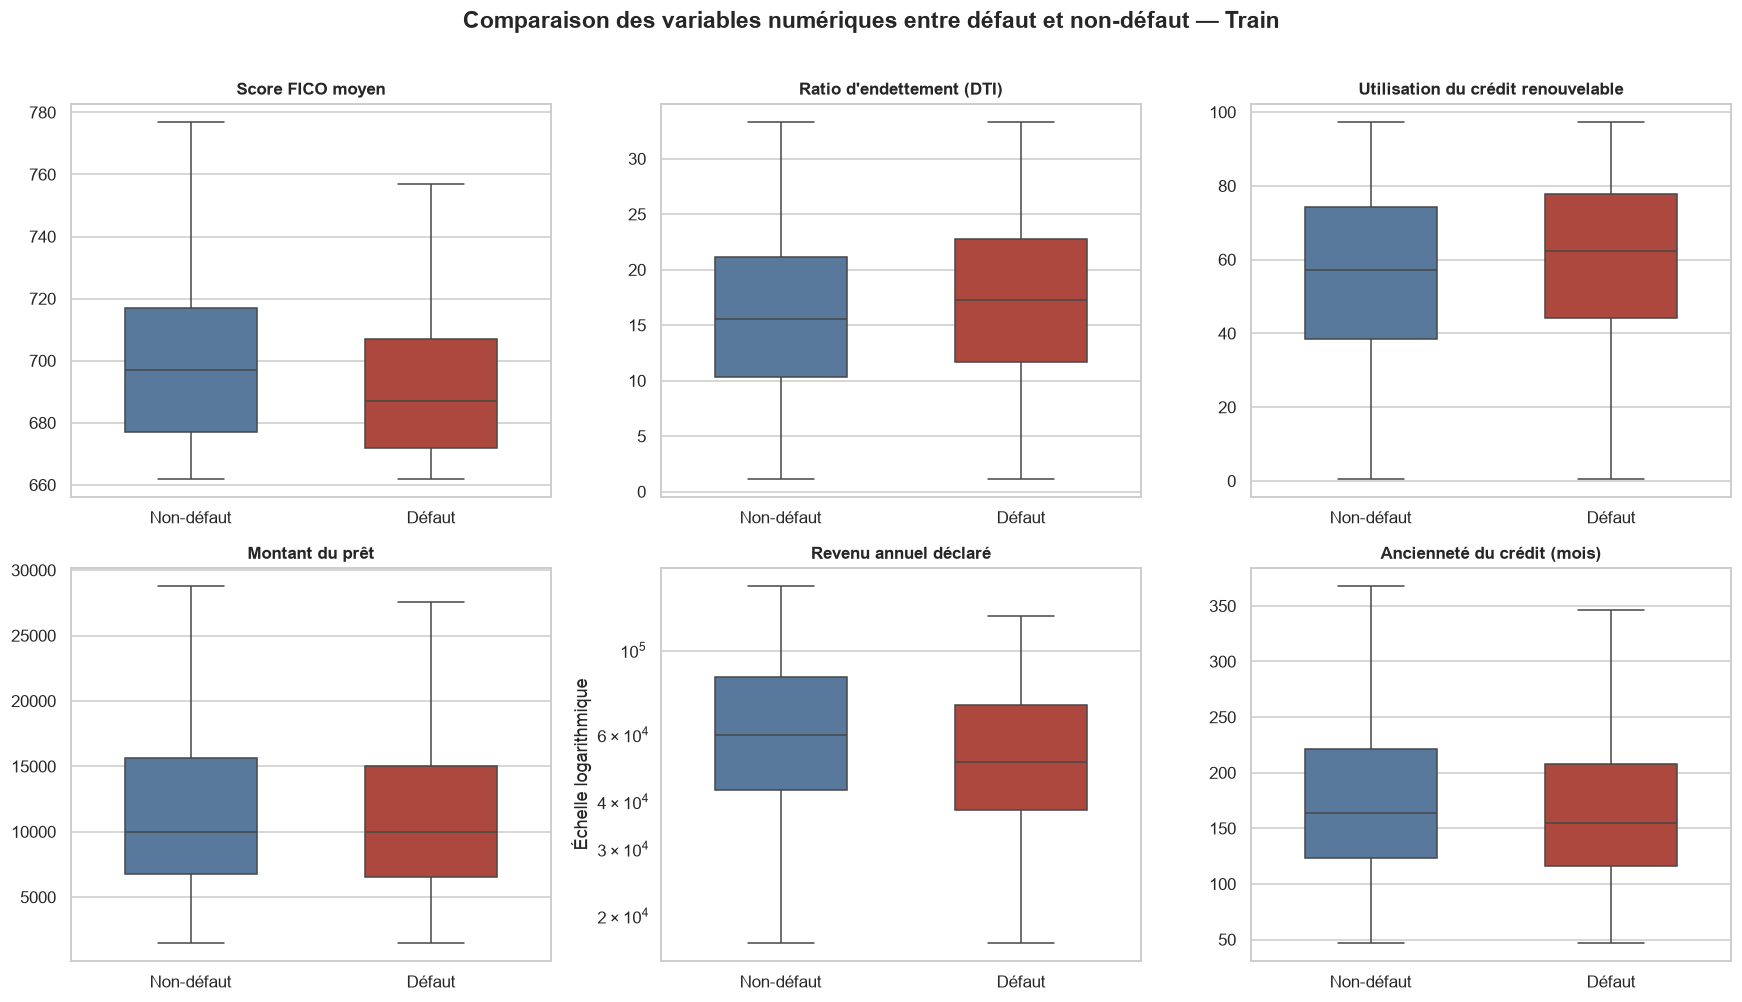

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/eda_numerical_boxplots_by_target.png


In [15]:
# ============================================================
# 5B. BOXPLOTS — VARIABLES NUMÉRIQUES PRIORITAIRES
# ============================================================

BOXPLOT_FEATURES = [
    "fico_score",
    "dti",
    "revol_util",
    "loan_amnt",
    "annual_inc",
    "credit_history_months",
]

BOXPLOT_LABELS = {
    "fico_score": "Score FICO moyen",
    "dti": "Ratio d'endettement (DTI)",
    "revol_util": "Utilisation du crédit renouvelable",
    "loan_amnt": "Montant du prêt",
    "annual_inc": "Revenu annuel déclaré",
    "credit_history_months": "Ancienneté du crédit (mois)",
}

target_labels = {
    0: "Non-défaut",
    1: "Défaut",
}

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 9),
)

axes = axes.flatten()

for ax, feature in zip(axes, BOXPLOT_FEATURES):
    lower_bound = train_df[feature].quantile(0.01)
    upper_bound = train_df[feature].quantile(0.99)

    plot_df = train_df.loc[
        train_df[feature].between(
            lower_bound,
            upper_bound,
            inclusive="both",
        ),
        [feature, TARGET],
    ].copy()

    plot_df["target_label"] = plot_df[TARGET].map(
        target_labels
    )

    sns.boxplot(
        data=plot_df,
        x="target_label",
        y=feature,
        order=["Non-défaut", "Défaut"],
        palette={
            "Non-défaut": "#4C78A8",
            "Défaut": "#C0392B",
        },
        showfliers=False,
        width=0.55,
        ax=ax,
    )

    ax.set_title(
        BOXPLOT_LABELS[feature],
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Une échelle logarithmique améliore la lecture des montants très asymétriques.
    if feature == "annual_inc":
        ax.set_yscale("log")
        ax.set_ylabel("Échelle logarithmique")

fig.suptitle(
    "Comparaison des variables numériques entre défaut et non-défaut — Train",
    fontsize=15,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()

figure_path = (
    OUTPUT_FIGURES_DIR
    / "eda_numerical_boxplots_by_target.png"
)

plt.savefig(
    figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(f"Figure exportée : {figure_path}")


### Lecture des boxplots

Les boxplots confirment les relations observées avec les déciles. Les prêts en
défaut sont associés à un score FICO plus faible, à un niveau d'endettement et
d'utilisation du crédit renouvelable plus élevé, ainsi qu'à un revenu et une
ancienneté de crédit généralement plus faibles.

Le montant du prêt présente des distributions très proches entre les deux
classes. Son intérêt potentiel ne semble pas linéaire et sera réévalué dans
les modèles, notamment dans XGBoost qui peut apprendre des interactions avec
le revenu, l'endettement et le score FICO.

Les extrêmes n'ont été masqués que pour la lisibilité. Le traitement des
valeurs atypiques sera intégré aux pipelines de modélisation et estimé
exclusivement à partir du jeu d'entraînement.


## Analyse des variables catégorielles

Cette section étudie les trois variables catégorielles retenues pour la V1 :

- `home_ownership` ;
- `purpose` ;
- `verification_status`.

Pour chaque modalité, nous observons le volume de prêts, sa part dans le
portefeuille et son taux de défaut. Les catégories peu fréquentes doivent être
interprétées avec prudence : leur taux de défaut peut être plus volatil.

Les résultats sont calculés exclusivement sur le jeu d'entraînement.


In [16]:
# ============================================================
# 6. ANALYSE DES VARIABLES CATÉGORIELLES
# ============================================================

CATEGORICAL_FEATURES = [
    "home_ownership",
    "purpose",
    "verification_status",
]

CATEGORICAL_LABELS = {
    "home_ownership": "Statut d'occupation du logement",
    "purpose": "Motif du prêt",
    "verification_status": "Statut de vérification",
}

assert all(
    feature in train_df.columns
    for feature in CATEGORICAL_FEATURES
), "Une variable catégorielle attendue est absente du train."


def compute_categorical_default_summary(
    dataframe: pd.DataFrame,
    feature: str,
    target: str,
) -> pd.DataFrame:
    """
    Produit le volume et le taux de défaut par modalité.

    Les valeurs manquantes sont conservées sous la modalité explicite
    'Missing' afin de mesurer leur profil de risque.
    """
    summary = (
        dataframe
        .assign(
            **{
                feature: dataframe[feature]
                .fillna("Missing")
                .astype("string")
            }
        )
        .groupby(feature, observed=True)
        .agg(
            n_loans=(target, "size"),
            n_defaults=(target, "sum"),
            default_rate=(target, "mean"),
        )
        .reset_index()
        .rename(
            columns={
                feature: "category",
            }
        )
    )

    summary["portfolio_share"] = (
        summary["n_loans"]
        / summary["n_loans"].sum()
    )

    summary["variable"] = feature

    return (
        summary
        .sort_values(
            ["default_rate", "n_loans"],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )


categorical_summary = pd.concat(
    [
        compute_categorical_default_summary(
            dataframe=train_df,
            feature=feature,
            target=TARGET,
        )
        for feature in CATEGORICAL_FEATURES
    ],
    ignore_index=True,
)

categorical_summary = categorical_summary[
    [
        "variable",
        "category",
        "n_loans",
        "n_defaults",
        "portfolio_share",
        "default_rate",
    ]
]

display(categorical_summary)


,variable,category,n_loans,n_defaults,portfolio_share,default_rate
0,home_ownership,OTHER,175,30,0.0010,0.1714
1,home_ownership,RENT,77040,11054,0.4453,0.1435
2,home_ownership,OWN,14587,1905,0.0843,0.1306
3,home_ownership,MORTGAGE,81186,8519,0.4693,0.1049
4,purpose,small_business,3345,732,0.0193,0.2188
5,purpose,renewable_energy,183,32,0.0011,0.1749
6,purpose,educational,309,49,0.0018,0.1586
7,purpose,other,10229,1600,0.0591,0.1564
8,purpose,moving,1428,221,0.0083,0.1548
9,purpose,medical,1879,290,0.0109,0.1543


### Volume et taux de défaut par modalité

Les deux graphiques sont complémentaires :

- le premier montre la composition du portefeuille ;
- le second montre le niveau de risque de chaque catégorie.

Les modalités sont affichées dans le même ordre, décroissant selon leur taux
de défaut. Cela permet d'identifier immédiatement les segments plus risqués,
tout en distinguant les catégories réellement représentées des petits groupes
potentiellement volatils.


In [17]:
#Fonction de visualisation
def plot_categorical_feature(
    summary_df: pd.DataFrame,
    feature: str,
    feature_label: str,
) -> None:
    """Affiche volume et taux de défaut par modalité catégorielle."""
    feature_df = (
        summary_df
        .loc[
            summary_df["variable"] == feature
        ]
        .copy()
        .sort_values(
            "default_rate",
            ascending=True,
        )
    )

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(15, max(4.5, len(feature_df) * 0.55)),
        gridspec_kw={
            "width_ratios": [1.15, 1],
        },
    )

    # Volume
    sns.barplot(
        data=feature_df,
        y="category",
        x="n_loans",
        color="#4C78A8",
        ax=axes[0],
    )

    axes[0].set_title(
        f"Volume par modalité — {feature_label}",
        fontsize=12,
        fontweight="bold",
    )
    axes[0].set_xlabel("Nombre de prêts")
    axes[0].set_ylabel("")
    axes[0].xaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda value, _: f"{value / 1_000:.0f} k"
        )
    )

    # Risque
    sns.barplot(
        data=feature_df,
        y="category",
        x="default_rate",
        color="#C0392B",
        ax=axes[1],
    )

    for container in axes[1].containers:
        axes[1].bar_label(
            container,
            labels=[
                f"{value:.1%}"
                for value in feature_df["default_rate"]
            ],
            padding=4,
            fontsize=9,
        )

    axes[1].set_title(
        f"Taux de défaut par modalité — {feature_label}",
        fontsize=12,
        fontweight="bold",
    )
    axes[1].set_xlabel("Taux de défaut")
    axes[1].set_ylabel("")
    axes[1].xaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda value, _: f"{value:.0%}"
        )
    )
    axes[1].set_xlim(
        0,
        feature_df["default_rate"].max() * 1.20,
    )

    fig.suptitle(
        f"{feature_label} — Train",
        fontsize=15,
        fontweight="bold",
        y=1.02,
    )

    plt.tight_layout()

    figure_path = (
        OUTPUT_FIGURES_DIR
        / f"eda_{feature}_volume_and_default_rate.png"
    )

    plt.savefig(
        figure_path,
        dpi=160,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Figure exportée : {figure_path}")


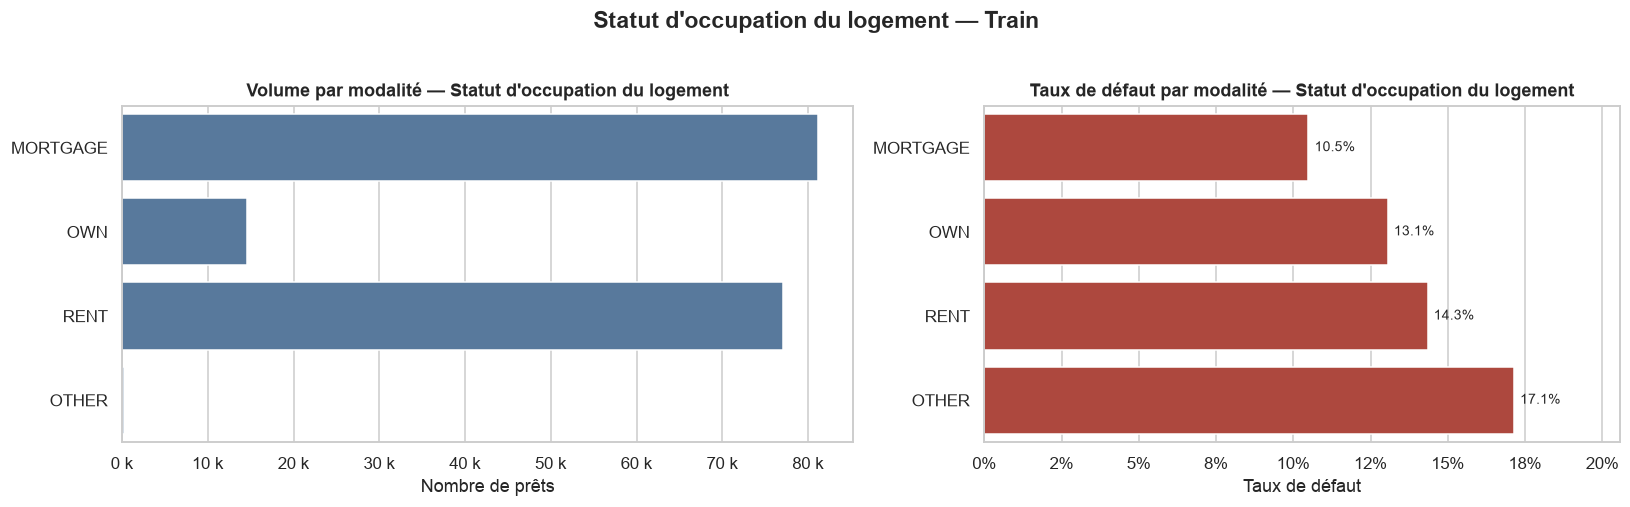

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/eda_home_ownership_volume_and_default_rate.png


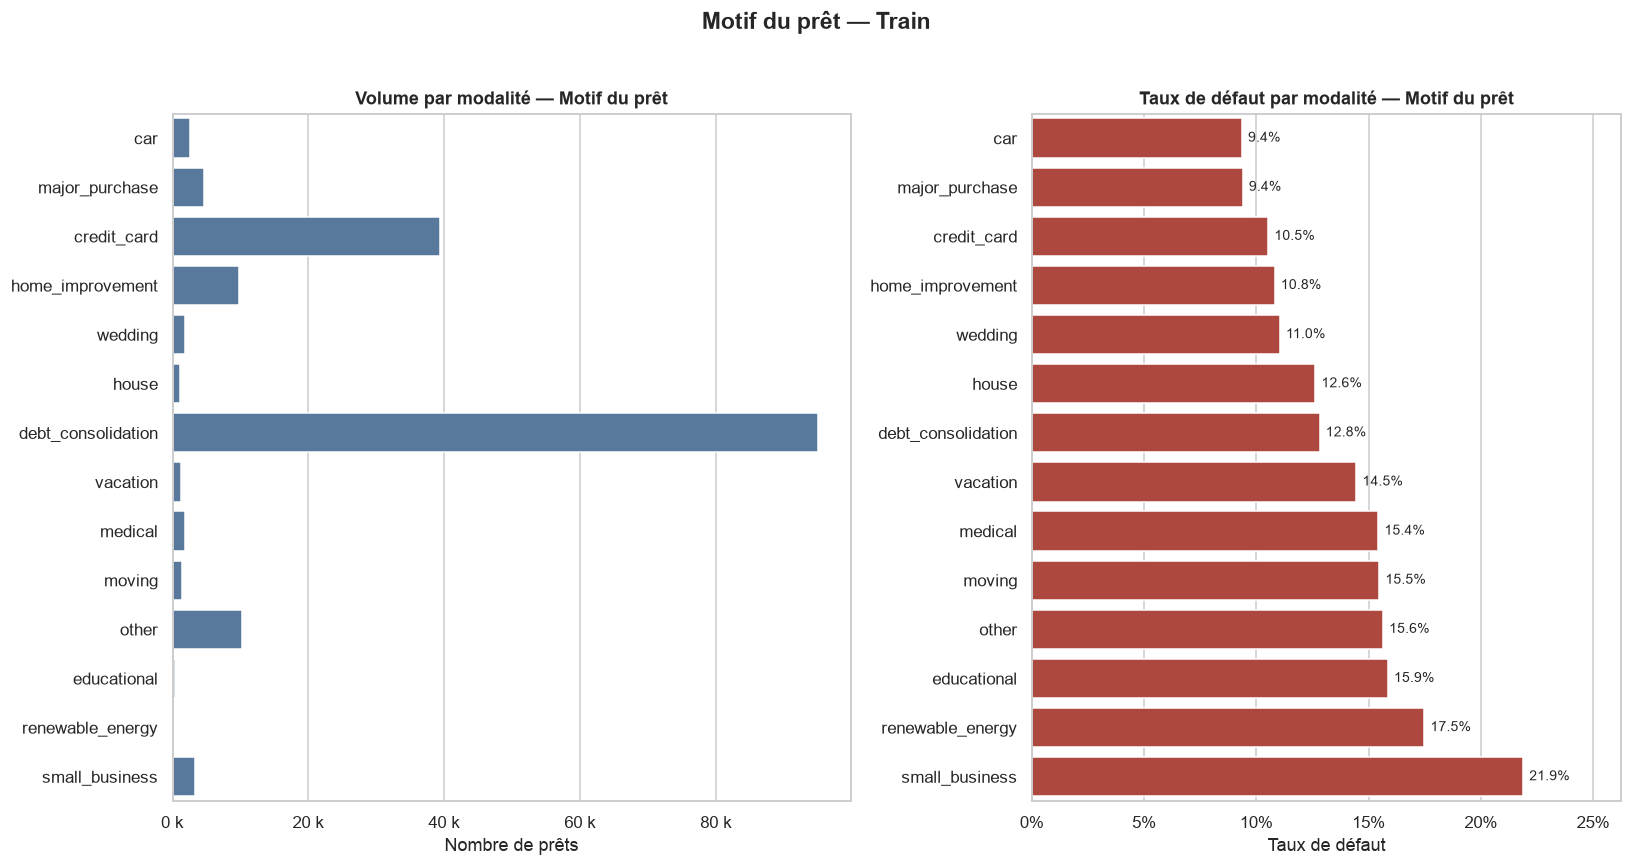

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/eda_purpose_volume_and_default_rate.png


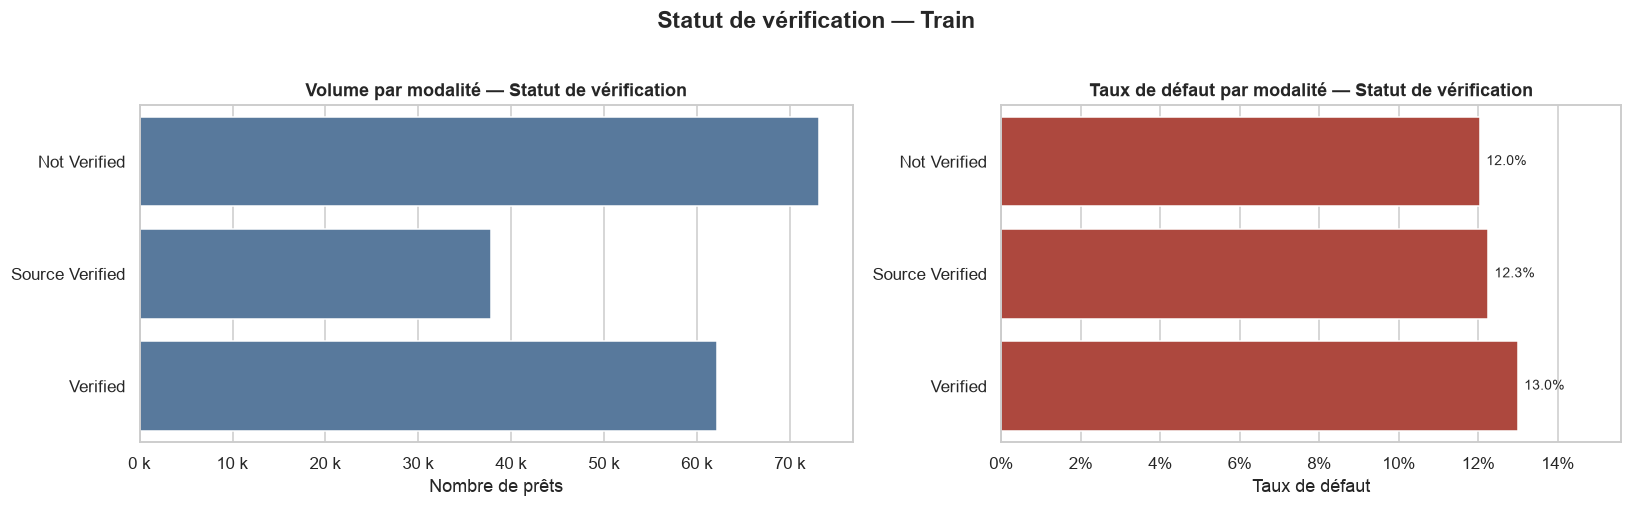

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/eda_verification_status_volume_and_default_rate.png


In [18]:
#Generation des trois graphique
for feature in CATEGORICAL_FEATURES:
    plot_categorical_feature(
        summary_df=categorical_summary,
        feature=feature,
        feature_label=CATEGORICAL_LABELS[feature],
    )


### Catégories rares

Une catégorie peu représentée peut afficher un taux de défaut instable. Nous
identifions les modalités qui comptent moins de 1 % du portefeuille train afin
d'évaluer si un regroupement dans `Other` serait pertinent lors de
l'encodage.


In [19]:
#Stabilité et categories
RARE_CATEGORY_THRESHOLD = 0.01

rare_categories_summary = (
    categorical_summary
    .assign(
        is_rare=lambda dataframe: (
            dataframe["portfolio_share"]
            < RARE_CATEGORY_THRESHOLD
        )
    )
    .sort_values(
        ["variable", "portfolio_share"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)

display(
    rare_categories_summary.loc[
        rare_categories_summary["is_rare"]
    ]
)


,variable,category,n_loans,n_defaults,portfolio_share,default_rate,is_rare
0,home_ownership,OTHER,175,30,0.0010,0.1714,True
4,purpose,renewable_energy,183,32,0.0011,0.1749,True
5,purpose,educational,309,49,0.0018,0.1586,True
6,purpose,house,1061,134,0.0061,0.1263,True
7,purpose,vacation,1176,170,0.0068,0.1446,True
8,purpose,moving,1428,221,0.0083,0.1548,True


In [22]:
#Export
categorical_summary.to_csv(
    OUTPUT_TABLES_DIR / "eda_categorical_summary.csv",
    index=False,
)

rare_categories_summary.to_csv(
    OUTPUT_TABLES_DIR / "eda_rare_categories.csv",
    index=False,
)

print("Tables exportées :")
print(
    "-",
    OUTPUT_TABLES_DIR / "eda_categorical_summary.csv",
)
print(
    "-",
    OUTPUT_TABLES_DIR / "eda_rare_categories.csv",
)


Tables exportées :
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/eda_categorical_summary.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/eda_rare_categories.csv


### Interprétation

Les variables catégorielles permettent d'identifier des segments de
portefeuille dont le risque diffère de la moyenne globale. Les modalités
présentes dans le train sont suffisamment connues pour être encodées dans les
modèles, sous réserve d'un traitement explicite des catégories rares.

Les taux de défaut des catégories peu fréquentes doivent être interprétés avec
prudence. Si leur poids est limité, elles pourront être regroupées dans une
modalité `Other` dans le pipeline, selon une règle estimée uniquement sur le
train.

Les écarts de taux de défaut entre modalités ne constituent pas une décision
automatique de crédit. Ils serviront à évaluer la valeur prédictive marginale
de ces variables dans les modèles et à vérifier leur stabilité temporelle.


Les trois variables catégorielles apportent un signal utile, surtout  purpose  et  home_ownership . Les modalités rares sont identifiées ; elles devront être regroupées dans la scorecard, tandis que XGBoost pourra les traiter avec un encodage adapté.[Pièce jointe +4]
Statut de logement
Le risque augmente progressivement de 10,5% pour les emprunteurs avec hypothèque à 13,1% pour les propriétaires, puis 14,3% pour les locataires. La modalité  OTHER  atteint 17,1%, mais ne représente que 175 prêts ; elle doit rester regroupée et être interprétée avec prudence.[Pièce jointe +2]
 MORTGAGE  représente 46,93% du train et  RENT  44,53%, ce qui rend leur comparaison particulièrement robuste.  home_ownership  est donc une variable utile, avec un ordre de risque stable et facile à intégrer dans une scorecard.[Pièce jointe]
Motif du prêt
 debt_consolidation  domine largement le portefeuille avec 95 006 prêts, soit 54,92%, et présente un taux de défaut de 12,82%, proche de la moyenne globale. Les catégories à plus faible risque sont  car  et  major_purchase , autour de 9,4%, puis  credit_card , à 10,5%.[Pièce jointe +1]
Les taux les plus élevés apparaissent pour  small_business  (21,88%),  renewable_energy  (17,49%),  educational  (15,86%),  other  (15,64%),  moving  (15,48%) et  medical  (15,43%). Les trois premières catégories sont peu représentées — notamment  renewable_energy  (183 prêts) et  educational  (309) — donc leur risque apparent est plus incertain.  small_business , en revanche, compte 3 345 prêts et son niveau de risque élevé est suffisamment documenté pour être conservé comme catégorie distincte.[Pièce jointe +2]
Vérification
Le statut de vérification a un signal plus faible mais régulier : 12,0% pour  Not Verified , 12,2% pour  Source Verified  et 13,0% pour  Verified . Les trois modalités ont des volumes substantiels, de 37 806 à 73 086 prêts, ce qui rend cet écart crédible plutôt que purement aléatoire.[Pièce jointe +1]
Le fait que  Verified  soit le groupe le plus risqué ne signifie pas que la vérification cause le défaut : elle peut refléter une sélection opérationnelle, par exemple le fait que les dossiers plus risqués soient davantage vérifiés.

### Interprétation

Le statut d'occupation du logement présente une relation ordonnée avec le
risque : les emprunteurs avec hypothèque ont le taux de défaut le plus faible,
suivis des propriétaires puis des locataires. La modalité `OTHER` est rare et
restera regroupée afin de limiter l'instabilité de son estimation.

Le motif du prêt apporte un signal discriminant plus important. Les prêts pour
petites entreprises, énergie renouvelable, études, déménagement ou dépenses
médicales sont associés à des taux de défaut supérieurs à la moyenne. Les
catégories à faible volume seront regroupées dans une modalité `Other` pour la
scorecard, à l'exception de `small_business`, dont le volume et le risque
justifient une catégorie distincte.

Le statut de vérification présente une différence de risque modérée, mais ses
trois catégories disposent de volumes suffisants pour être conservées. Ce lien
doit être interprété comme un signal prédictif et non comme un effet causal de
la vérification.


## Stabilité temporelle des données

Avant de modéliser, nous vérifions si les jeux validation et test ont des
distributions comparables au train. Le train sert de référence car tous les
traitements — imputation, plafonnement, regroupement des catégories et
encodage — devront être appris exclusivement sur cette partition.

Nous mesurons la dérive avec le Population Stability Index (PSI) :

- PSI inférieur à 0,10 : stabilité généralement acceptable ;
- PSI entre 0,10 et 0,25 : dérive modérée, à surveiller ;
- PSI supérieur ou égal à 0,25 : dérive importante.

Le PSI est un indicateur descriptif. Il complète l'analyse des taux de défaut
et ne remplace pas l'évaluation finale des modèles sur validation et test.


In [24]:
# ============================================================
# 7. STABILITÉ TEMPORELLE : TRAIN VS VALIDATION VS TEST
# ============================================================

VALIDATION_PATH = DATA_PROCESSED_DIR / "validation_v1.parquet"
TEST_PATH = DATA_PROCESSED_DIR / "test_v1.parquet"

validation_df = pd.read_parquet(VALIDATION_PATH)
test_df = pd.read_parquet(TEST_PATH)

train_columns = list(train_df.columns)
train_column_set = set(train_columns)


def compare_schema(
    reference_df: pd.DataFrame,
    comparison_df: pd.DataFrame,
    comparison_name: str,
) -> None:
    """Affiche les différences de colonnes par rapport au train."""
    reference_columns = set(reference_df.columns)
    comparison_columns = set(comparison_df.columns)

    extra_columns = sorted(
        comparison_columns - reference_columns
    )
    missing_columns = sorted(
        reference_columns - comparison_columns
    )

    print(f"\n--- Schéma : {comparison_name} ---")
    print(f"Colonnes train      : {len(reference_columns)}")
    print(f"Colonnes {comparison_name.lower():<9}: {len(comparison_columns)}")
    print(f"Colonnes en plus    : {extra_columns or 'Aucune'}")
    print(f"Colonnes manquantes : {missing_columns or 'Aucune'}")


compare_schema(
    reference_df=train_df,
    comparison_df=validation_df,
    comparison_name="Validation",
)

compare_schema(
    reference_df=train_df,
    comparison_df=test_df,
    comparison_name="Test",
)



--- Schéma : Validation ---
Colonnes train      : 26
Colonnes validation: 25
Colonnes en plus    : Aucune
Colonnes manquantes : ['issue_year']

--- Schéma : Test ---
Colonnes train      : 26
Colonnes test     : 25
Colonnes en plus    : Aucune
Colonnes manquantes : ['issue_year']


In [26]:
# Colonnes créées dans le notebook pour l'EDA, absentes des fichiers source.
EDA_DERIVED_COLUMNS = {
    "issue_year",
}

# Schéma attendu : colonnes natives du train uniquement.
source_train_columns = [
    column
    for column in train_df.columns
    if column not in EDA_DERIVED_COLUMNS
]

source_train_column_set = set(source_train_columns)

missing_in_validation = sorted(
    source_train_column_set - set(validation_df.columns)
)

missing_in_test = sorted(
    source_train_column_set - set(test_df.columns)
)

extra_in_validation = sorted(
    set(validation_df.columns) - source_train_column_set
)

extra_in_test = sorted(
    set(test_df.columns) - source_train_column_set
)

print("Colonnes absentes de validation :", missing_in_validation)
print("Colonnes absentes du test       :", missing_in_test)
print("Colonnes supplémentaires validation :", extra_in_validation)
print("Colonnes supplémentaires test       :", extra_in_test)

assert not missing_in_validation, (
    "Colonnes sources absentes de validation : "
    f"{missing_in_validation}"
)

assert not missing_in_test, (
    "Colonnes sources absentes du test : "
    f"{missing_in_test}"
)

# On aligne les trois partitions sur les seules colonnes présentes dans les fichiers source.
train_for_stability = train_df.loc[:, source_train_columns].copy()

validation_df = validation_df.loc[
    :,
    source_train_columns,
].copy()

test_df = test_df.loc[
    :,
    source_train_columns,
].copy()

assert list(train_for_stability.columns) == source_train_columns
assert list(validation_df.columns) == source_train_columns
assert list(test_df.columns) == source_train_columns

splits = {
    "Train": train_for_stability,
    "Validation": validation_df,
    "Test": test_df,
}

print("Schémas sources alignés avec succès.")


Colonnes absentes de validation : []
Colonnes absentes du test       : []
Colonnes supplémentaires validation : []
Colonnes supplémentaires test       : []
Schémas sources alignés avec succès.


In [30]:
# ============================================================
# SYNTHÈSE DES PARTITIONS TEMPORELLES
# ============================================================

split_overview = pd.DataFrame(
    [
        {
            "split": split_name,
            "n_loans": len(dataframe),
            "n_defaults": int(dataframe[TARGET].sum()),
            "default_rate": dataframe[TARGET].mean(),
        }
        for split_name, dataframe in splits.items()
    ]
)

split_overview["portfolio_share"] = (
    split_overview["n_loans"]
    / split_overview["n_loans"].sum()
)

split_overview = (
    split_overview
    .set_index("split")
    .reindex(["Train", "Validation", "Test"])
    .reset_index()
)

display(split_overview)


,split,n_loans,n_defaults,default_rate,portfolio_share
0,Train,172988,21508,0.1243,0.2797
1,Validation,162570,22315,0.1373,0.2628
2,Test,283026,42132,0.1489,0.4575


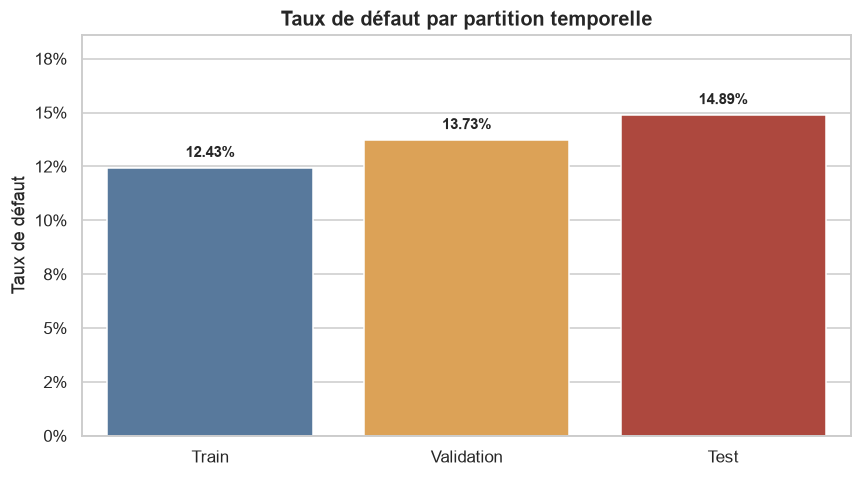

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/eda_default_rate_by_split.png


In [32]:
# ============================================================
# GRAPHIQUE DU TAUX DE DÉFAUT PAR PARTITION
# ============================================================

split_colors = {
    "Train": "#4C78A8",
    "Validation": "#F2A541",
    "Test": "#C0392B",
}

fig, ax = plt.subplots(figsize=(8, 4.5))

sns.barplot(
    data=split_overview,
    x="split",
    y="default_rate",
    hue="split",
    palette=split_colors,
    legend=False,
    ax=ax,
)

# Annotation robuste, indépendante de ax.bar_label().
for patch, (_, row) in zip(
    ax.patches,
    split_overview.iterrows(),
):
    bar_height = patch.get_height()

    ax.annotate(
        text=f"{row['default_rate']:.2%}",
        xy=(
            patch.get_x() + patch.get_width() / 2,
            bar_height,
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title(
    "Taux de défaut par partition temporelle",
    fontsize=13,
    fontweight="bold",
)

ax.set_xlabel("")
ax.set_ylabel("Taux de défaut")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{value:.0%}"
    )
)

ax.set_ylim(
    0,
    split_overview["default_rate"].max() * 1.25,
)

plt.tight_layout()

figure_path = (
    OUTPUT_FIGURES_DIR
    / "eda_default_rate_by_split.png"
)

plt.savefig(
    figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(f"Figure exportée : {figure_path}")


In [33]:
NUMERIC_FEATURES_FOR_PSI = [
    "fico_score",
    "dti",
    "revol_util",
    "loan_amnt",
    "annual_inc",
    "credit_history_months",
]

assert all(
    feature in train_for_stability.columns
    for feature in NUMERIC_FEATURES_FOR_PSI
), "Au moins une variable numérique PSI est absente du train."


def compute_psi(
    reference: pd.Series,
    comparison: pd.Series,
    n_bins: int = 10,
    epsilon: float = 1e-6,
) -> float:
    """
    Calcule un PSI en utilisant des déciles appris sur la référence.

    Les bornes sont calculées sur le train uniquement afin d'éviter toute fuite
    d'information depuis validation ou test.
    """
    reference = reference.dropna()
    comparison = comparison.dropna()

    bin_edges = np.unique(
        np.quantile(
            reference,
            q=np.linspace(0, 1, n_bins + 1),
        )
    )

    if len(bin_edges) < 3:
        return np.nan

    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    reference_counts = pd.cut(
        reference,
        bins=bin_edges,
        include_lowest=True,
    ).value_counts(
        sort=False
    )

    comparison_counts = pd.cut(
        comparison,
        bins=bin_edges,
        include_lowest=True,
    ).value_counts(
        sort=False
    )

    reference_share = (
        reference_counts / reference_counts.sum()
    ).clip(lower=epsilon)

    comparison_share = (
        comparison_counts / comparison_counts.sum()
    ).clip(lower=epsilon)

    psi = (
        (comparison_share - reference_share)
        * np.log(comparison_share / reference_share)
    ).sum()

    return float(psi)


def psi_interpretation(psi_value: float) -> str:
    """Retourne une interprétation standardisée du PSI."""
    if pd.isna(psi_value):
        return "Non calculable"

    if psi_value < 0.10:
        return "Stable"

    if psi_value < 0.25:
        return "Dérive modérée"

    return "Dérive importante"


In [34]:
numeric_psi_rows = []

for feature in NUMERIC_FEATURES_FOR_PSI:
    for split_name in ["Validation", "Test"]:
        psi_value = compute_psi(
            reference=train_for_stability[feature],
            comparison=splits[split_name][feature],
        )

        numeric_psi_rows.append(
            {
                "feature": feature,
                "split": split_name,
                "psi": psi_value,
                "interpretation": psi_interpretation(
                    psi_value
                ),
            }
        )

numeric_psi_summary = (
    pd.DataFrame(numeric_psi_rows)
    .sort_values(
        ["psi", "feature"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(numeric_psi_summary)


,feature,split,psi,interpretation
0,dti,Test,0.0844,Stable
1,fico_score,Validation,0.0734,Stable
2,fico_score,Test,0.0560,Stable
3,credit_history_months,Test,0.0557,Stable
4,credit_history_months,Validation,0.0463,Stable
5,revol_util,Test,0.0364,Stable
6,dti,Validation,0.0347,Stable
7,revol_util,Validation,0.0246,Stable
8,loan_amnt,Test,0.0229,Stable
9,loan_amnt,Validation,0.0139,Stable


### Dérive des catégories

Pour les variables catégorielles, le PSI compare les proportions de chaque
modalité avec celles observées dans le train. Les catégories inédites dans
validation ou test sont explicitement prises en compte ; elles devront être
gérées par le pipeline sans provoquer d'erreur.


In [35]:
def compute_categorical_psi(
    reference: pd.Series,
    comparison: pd.Series,
    epsilon: float = 1e-6,
) -> float:
    """
    Calcule le PSI catégoriel entre une référence et une partition de comparaison.
    """
    reference = (
        reference
        .fillna("Missing")
        .astype("string")
    )

    comparison = (
        comparison
        .fillna("Missing")
        .astype("string")
    )

    all_categories = (
        reference
        .value_counts()
        .index
        .union(
            comparison
            .value_counts()
            .index
        )
    )

    reference_share = (
        reference
        .value_counts(normalize=True)
        .reindex(
            all_categories,
            fill_value=0,
        )
        .clip(lower=epsilon)
    )

    comparison_share = (
        comparison
        .value_counts(normalize=True)
        .reindex(
            all_categories,
            fill_value=0,
        )
        .clip(lower=epsilon)
    )

    psi = (
        (comparison_share - reference_share)
        * np.log(comparison_share / reference_share)
    ).sum()

    return float(psi)


categorical_psi_rows = []

for feature in CATEGORICAL_FEATURES:
    for split_name in ["Validation", "Test"]:
        psi_value = compute_categorical_psi(
            reference=train_for_stability[feature],
            comparison=splits[split_name][feature],
        )

        categorical_psi_rows.append(
            {
                "feature": feature,
                "split": split_name,
                "psi": psi_value,
                "interpretation": psi_interpretation(
                    psi_value
                ),
            }
        )

categorical_psi_summary = (
    pd.DataFrame(categorical_psi_rows)
    .sort_values(
        ["psi", "feature"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(categorical_psi_summary)


,feature,split,psi,interpretation
0,verification_status,Test,0.1968,Dérive modérée
1,verification_status,Validation,0.1226,Dérive modérée
2,purpose,Test,0.1063,Dérive modérée
3,purpose,Validation,0.0927,Stable
4,home_ownership,Test,0.0146,Stable
5,home_ownership,Validation,0.0089,Stable


In [36]:
psi_summary = (
    pd.concat(
        [
            numeric_psi_summary.assign(
                feature_type="Numérique"
            ),
            categorical_psi_summary.assign(
                feature_type="Catégorielle"
            ),
        ],
        ignore_index=True,
    )
    .sort_values(
        ["psi", "split"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(psi_summary)


,feature,split,psi,interpretation,feature_type
0,verification_status,Test,0.1968,Dérive modérée,Catégorielle
1,verification_status,Validation,0.1226,Dérive modérée,Catégorielle
2,purpose,Test,0.1063,Dérive modérée,Catégorielle
3,purpose,Validation,0.0927,Stable,Catégorielle
4,dti,Test,0.0844,Stable,Numérique
5,fico_score,Validation,0.0734,Stable,Numérique
6,fico_score,Test,0.0560,Stable,Numérique
7,credit_history_months,Test,0.0557,Stable,Numérique
8,credit_history_months,Validation,0.0463,Stable,Numérique
9,revol_util,Test,0.0364,Stable,Numérique


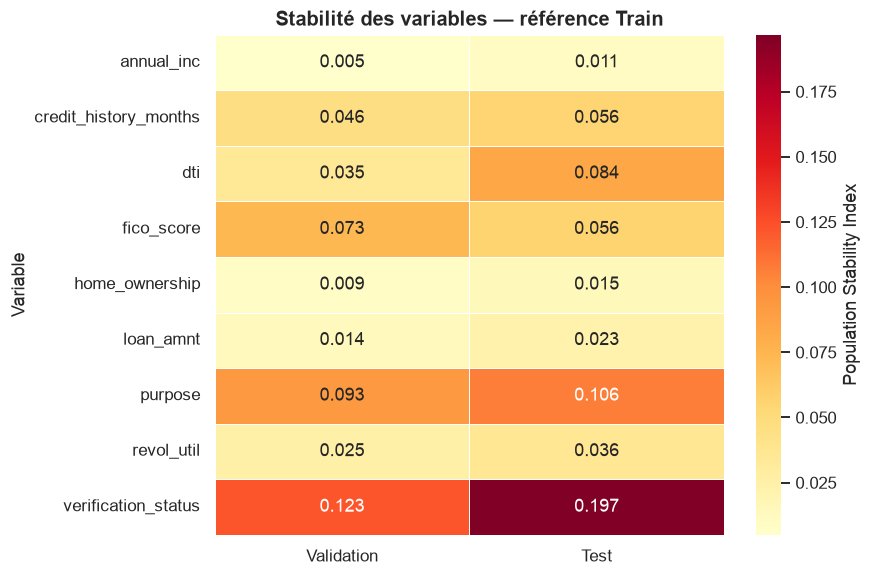

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/eda_psi_train_vs_validation_test.png


In [37]:
psi_heatmap = (
    psi_summary
    .pivot(
        index="feature",
        columns="split",
        values="psi",
    )
    .reindex(
        columns=["Validation", "Test"],
    )
)

fig, ax = plt.subplots(
    figsize=(8, max(4.5, len(psi_heatmap) * 0.6))
)

sns.heatmap(
    psi_heatmap,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={
        "label": "Population Stability Index",
    },
    ax=ax,
)

ax.set_title(
    "Stabilité des variables — référence Train",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("")
ax.set_ylabel("Variable")

plt.tight_layout()

figure_path = (
    OUTPUT_FIGURES_DIR
    / "eda_psi_train_vs_validation_test.png"
)

plt.savefig(
    figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(f"Figure exportée : {figure_path}")


In [38]:
split_overview.to_csv(
    OUTPUT_TABLES_DIR / "eda_split_overview.csv",
    index=False,
)

numeric_psi_summary.to_csv(
    OUTPUT_TABLES_DIR / "eda_numeric_psi.csv",
    index=False,
)

categorical_psi_summary.to_csv(
    OUTPUT_TABLES_DIR / "eda_categorical_psi.csv",
    index=False,
)

psi_summary.to_csv(
    OUTPUT_TABLES_DIR / "eda_psi_summary.csv",
    index=False,
)

print("Tables exportées :")
print("-", OUTPUT_TABLES_DIR / "eda_split_overview.csv")
print("-", OUTPUT_TABLES_DIR / "eda_numeric_psi.csv")
print("-", OUTPUT_TABLES_DIR / "eda_categorical_psi.csv")
print("-", OUTPUT_TABLES_DIR / "eda_psi_summary.csv")


Tables exportées :
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/eda_split_overview.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/eda_numeric_psi.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/eda_categorical_psi.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/eda_psi_summary.csv


### Interprétation

Le train est utilisé comme distribution de référence. Les variables dont le
PSI reste inférieur à 0,10 entre train, validation et test sont considérées
comme stables pour la suite de la modélisation.

Les variables présentant un PSI compris entre 0,10 et 0,25 seront conservées
mais suivies attentivement. Une dérive supérieure ou égale à 0,25 nécessitera
une analyse spécifique : changement de population, évolution du portefeuille,
catégories nouvelles ou traitement de valeurs manquantes.

Les transformations et les règles de regroupement seront toujours ajustées sur
le train, puis appliquées telles quelles à validation et test. Cette discipline
garantit une évaluation sans fuite d'information.


In [39]:
# ============================================================
# PSI DES VARIABLES NUMÉRIQUES
# ============================================================

numeric_psi_rows = []

for feature in NUMERIC_FEATURES_FOR_PSI:
    for split_name in ["Validation", "Test"]:
        psi_value = compute_psi(
            reference=train_for_stability[feature],
            comparison=splits[split_name][feature],
        )

        numeric_psi_rows.append(
            {
                "feature": feature,
                "feature_type": "Numérique",
                "split": split_name,
                "psi": psi_value,
                "interpretation": psi_interpretation(
                    psi_value
                ),
            }
        )

numeric_psi_summary = (
    pd.DataFrame(numeric_psi_rows)
    .sort_values(
        ["psi", "feature"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(numeric_psi_summary)


,feature,feature_type,split,psi,interpretation
0,dti,Numérique,Test,0.0844,Stable
1,fico_score,Numérique,Validation,0.0734,Stable
2,fico_score,Numérique,Test,0.0560,Stable
3,credit_history_months,Numérique,Test,0.0557,Stable
4,credit_history_months,Numérique,Validation,0.0463,Stable
5,revol_util,Numérique,Test,0.0364,Stable
6,dti,Numérique,Validation,0.0347,Stable
7,revol_util,Numérique,Validation,0.0246,Stable
8,loan_amnt,Numérique,Test,0.0229,Stable
9,loan_amnt,Numérique,Validation,0.0139,Stable


In [40]:
# ============================================================
# PSI DES VARIABLES CATÉGORIELLES
# ============================================================

categorical_psi_rows = []

for feature in CATEGORICAL_FEATURES:
    for split_name in ["Validation", "Test"]:
        psi_value = compute_categorical_psi(
            reference=train_for_stability[feature],
            comparison=splits[split_name][feature],
        )

        categorical_psi_rows.append(
            {
                "feature": feature,
                "feature_type": "Catégorielle",
                "split": split_name,
                "psi": psi_value,
                "interpretation": psi_interpretation(
                    psi_value
                ),
            }
        )

categorical_psi_summary = (
    pd.DataFrame(categorical_psi_rows)
    .sort_values(
        ["psi", "feature"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(categorical_psi_summary)


,feature,feature_type,split,psi,interpretation
0,verification_status,Catégorielle,Test,0.1968,Dérive modérée
1,verification_status,Catégorielle,Validation,0.1226,Dérive modérée
2,purpose,Catégorielle,Test,0.1063,Dérive modérée
3,purpose,Catégorielle,Validation,0.0927,Stable
4,home_ownership,Catégorielle,Test,0.0146,Stable
5,home_ownership,Catégorielle,Validation,0.0089,Stable


,feature,feature_type,split,psi,interpretation
0,verification_status,Catégorielle,Test,0.1968,Dérive modérée
1,verification_status,Catégorielle,Validation,0.1226,Dérive modérée
2,purpose,Catégorielle,Test,0.1063,Dérive modérée
3,purpose,Catégorielle,Validation,0.0927,Stable
4,dti,Numérique,Test,0.0844,Stable
5,fico_score,Numérique,Validation,0.0734,Stable
6,fico_score,Numérique,Test,0.0560,Stable
7,credit_history_months,Numérique,Test,0.0557,Stable
8,credit_history_months,Numérique,Validation,0.0463,Stable
9,revol_util,Numérique,Test,0.0364,Stable


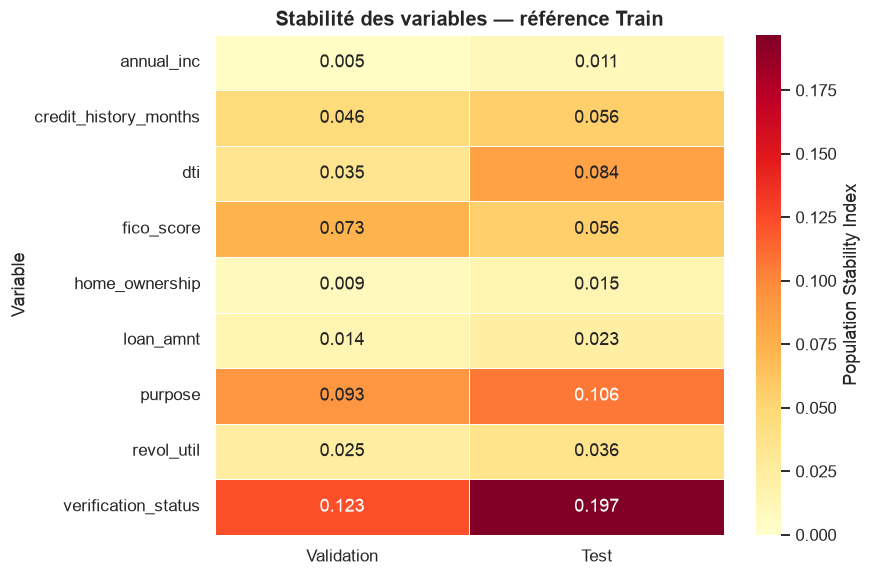

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/eda_psi_train_vs_validation_test.png


In [41]:
# ============================================================
# SYNTHÈSE PSI ET HEATMAP
# ============================================================

psi_summary = (
    pd.concat(
        [
            numeric_psi_summary,
            categorical_psi_summary,
        ],
        ignore_index=True,
    )
    .sort_values(
        ["psi", "split", "feature"],
        ascending=[False, True, True],
    )
    .reset_index(drop=True)
)

display(psi_summary)

psi_heatmap = (
    psi_summary
    .pivot(
        index="feature",
        columns="split",
        values="psi",
    )
    .reindex(
        columns=["Validation", "Test"],
    )
)

fig, ax = plt.subplots(
    figsize=(8, max(4.5, len(psi_heatmap) * 0.6))
)

sns.heatmap(
    psi_heatmap,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    vmin=0,
    cbar_kws={
        "label": "Population Stability Index",
    },
    ax=ax,
)

ax.set_title(
    "Stabilité des variables — référence Train",
    fontsize=13,
    fontweight="bold",
)

ax.set_xlabel("")
ax.set_ylabel("Variable")

plt.tight_layout()

figure_path = (
    OUTPUT_FIGURES_DIR
    / "eda_psi_train_vs_validation_test.png"
)

plt.savefig(
    figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(f"Figure exportée : {figure_path}")


In [42]:
#Export

split_overview.to_csv(
    OUTPUT_TABLES_DIR / "eda_split_overview.csv",
    index=False,
)

numeric_psi_summary.to_csv(
    OUTPUT_TABLES_DIR / "eda_numeric_psi.csv",
    index=False,
)

categorical_psi_summary.to_csv(
    OUTPUT_TABLES_DIR / "eda_categorical_psi.csv",
    index=False,
)

psi_summary.to_csv(
    OUTPUT_TABLES_DIR / "eda_psi_summary.csv",
    index=False,
)

print("Tables EDA exportées avec succès.")


Tables EDA exportées avec succès.


### Stabilité temporelle

Les variables numériques présentent une bonne stabilité entre train, validation
et test : tous leurs PSI sont inférieurs à 0,10. Elles sont donc conservées
pour la modélisation, avec une surveillance de l'endettement (`dti`), dont le
PSI atteint 0,084 dans le test tout en restant sous le seuil de dérive modérée.

Le statut d'occupation du logement est très stable. Le motif du prêt présente
une dérive limitée dans le test (PSI = 0,106), compatible avec un changement
modéré de la composition du portefeuille. Les catégories rares seront
regroupées selon des règles estimées sur le train uniquement.

Le statut de vérification présente la dérive la plus marquée (PSI = 0,123 sur
validation et 0,197 sur test), sans atteindre le seuil de dérive forte. La
variable est conservée pour la première version des modèles, mais son apport
sera comparé à une variante sans cette variable afin de vérifier que son gain
prédictif reste stable dans le temps.

Aucune variable n'est écartée à ce stade sur la seule base de la stabilité
temporelle. Tous les traitements seront ajustés exclusivement sur le train,
puis appliqués sans réapprentissage à validation et test.
